# 관련 단축키 설명

## 셀 코드 실행

* Shift + Enter: 현재 셀을 실행하고 다음 셀로 이동합니다. (가장 많이 사용)

* Ctrl + Enter: 현재 셀을 실행하고 현재 셀에 머무릅니다. 결과를 확인하고 코드를 계속 수정할 때 유용합니다. (Mac: Cmd + Enter)

## 코드 셀 만들기

* A: 현재 셀 위(Above)에 새로운 코드 셀을 추가합니다.

* B: 현재 셀 아래(Below)에 새로운 코드 셀을 추가합니다.

* Y: 마크다운 등 다른 타입의 셀을 다시 코드(Code) 셀로 변경합니다.

* M: 현재 셀을 마크다운(Markdown) 셀로 변경합니다.

* D , D: 키보드 알파벳 D를 연속으로 두 번 타닥 누르면 셀이 삭제됩니다.

보통 마크다운 셀을 새로 만들 때는 **B**를 눌러 아래에 빈 코드 셀을 만든 직후, 바로 **M**을 눌러 마크다운 셀로 변환해서 글을 작성하는 방식을 가장 많이 사용

<hr style="height: 5px; background-color: #39FF14; border: none;">

# **비전 노드 개발 관련 실험코드**

### 리얼센스 D435IF 기반 듀플로 단일 블럭 및 조립 객체 인식 상태 개발

주피터 노트북 -> 파이썬 라이브러리 변환 구조

## library requirement

In [ ]:
# !python --version
# !pip freeze > requirements.txt
# !cat requirements.txt
# 만약 requirement 설치시
# !python3 -m pip install -r requirements.txt

In [ ]:
# %pip install -r requirements.txt

<hr style="height: 5px; background-color: #39FF14; border: none;">

## **[윈도우 작업] - 그래픽 카드 쿠다 설정**

In [ ]:
# # 기존 토치 비전 삭제
# %pip uninstall -y torch torchvision torchaudio

In [ ]:
# # 파이토치 패키지 설치
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --no-cache-dir

In [8]:
import sys
import subprocess

print("=== 🖥️ 1. 시스템 및 그래픽카드 정보 (nvidia-smi) ===")
try:
    # 윈도우에 설치된 NVIDIA 드라이버 정보 출력
    result = subprocess.run(['nvidia-smi'], stdout=subprocess.PIPE, text=True)
    print(result.stdout)
except FileNotFoundError:
    print("⚠️ nvidia-smi 명령어를 찾을 수 없습니다. NVIDIA 드라이버가 없거나 환경변수에 등록되지 않았습니다.")

print("\n=== 🧠 2. 현재 파이썬 및 파이토치 환경 ===")
print(f"Python 실행 경로: {sys.executable}")
print(f"Python 버전: {sys.version.split(' ')[0]}")

try:
    import torch
    print(f"\nPyTorch 패키지 위치: {torch.__file__}")
    print(f"PyTorch 버전: {torch.__version__}")
    print(f"PyTorch 내장 CUDA 버전: {torch.version.cuda}")
    print(f"CUDA (GPU) 활성화 여부: {torch.cuda.is_available()}")
    
    if torch.cuda.is_available():
        print(f"사용 가능한 GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("⚠️ 진단 결과: 현재 파이토치는 GPU를 인식하지 못하는 'CPU 전용 버전'입니다.")
except ImportError:
    print("\n⚠️ 현재 환경에 파이토치(torch)가 설치되어 있지 않습니다.")

=== 🖥️ 1. 시스템 및 그래픽카드 정보 (nvidia-smi) ===
Sun May 31 03:00:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2060      WDDM  |   00000000:01:00.0  On |                  N/A |
| 32%   46C    P0             39W /  190W |    2004MiB /   6144MiB |      6%      Default |
|                                         |                        |                  N/A |
+-----

### **쿠다 설치 위치 확인**
* 만약 쿠다 설치가 잘못되었다고 생각되면 위에 셀을 통해서 위치랑 실행 위치 확인하기
* 다시 설치후, VSCODE 재실행

In [ ]:
## 파이토치 위치 불일치시 삭제용 코드

# import sys
# import subprocess

# packages = ["torch", "torchvision", "torchaudio"]

# print("🔥 좀비 파이토치 강제 박멸을 시작합니다...")
# for i in range(3):
#     print(f"🧹 삭제 시도 {i+1}회차...")
#     result = subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y"] + packages, capture_output=True, text=True)
#     if "Found existing installation" in result.stdout:
#         print(f"   -> 찌꺼기 발견 및 삭제 완료!")
#     elif "not installed" in result.stderr or "not installed" in result.stdout:
#         print(f"   -> 깨끗합니다 (더 이상 지울 게 없음).")

# print("✅ 완벽하게 지워졌습니다! 이제 2단계를 진행하세요.")

<hr style="height: 5px; background-color: #39FF14; border: none;">

## **라이브러리 변환**

In [ ]:
# 요구사항 설치
# %pip install -r requirements.txt

In [ ]:
# !pip install nbconvert
# !jupyter nbconvert --to script test.ipynb
# !pip install scikit-learn

Unable to create process using 'C:\Users\ULTIMATE NIGHTMARE\.conda\envs\PythonProject2\python.exe "C:\Users\ULTIMATE NIGHTMARE\.conda\envs\PythonProject2\Scripts\pip-script.py" install scikit-learn'


In [9]:
%pip install scikit-learn
%pip install nbconvert
# %jupyter nbconvert --to script test.ipynb

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [8]:
# scipy.ndimage.median_filter
import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

print("\n라이브러리 로드")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

라이브러리 로드


<hr style="height: 5px; background-color: #39FF14; border: none;">

## **욜로 확인용 코드**

In [9]:
# import cv2
# from ultralytics import YOLO

def yolo_check(model_path, image_path):
    """
    YOLO 모델과 이미지 경로를 받아 추론을 수행하고,
    결과가 그려진 RGB 이미지를 반환합니다.
    """
    # 1. 모델 로드
    print(f"🤖 '{model_path}' 로딩 중...")
    model = YOLO(model_path)

    # 2. GPU 할당 확인
    model.to('cuda')
    print(f"🚀 모델이 사용하는 하드웨어: {model.device}")

    # 3. 테스트 이미지 추론 (save=False로 변경하여 디스크 저장 생략, 메모리에서 바로 처리)
    print(f"🔍 추론 시작 (RTX 2060 가동)...")
    results = model.predict(source=image_path, save=False, conf=0.5, device=0)

    # 4. 결과 요약 출력
    result = results[0] # 첫 번째 이미지에 대한 결과 객체
    print(f"\n✅ 발견된 객체 수: {len(result.boxes)}")
    if result.masks is not None:
        print(f"🎨 추출된 마스크(폴리곤) 수: {len(result.masks)}")

    # 5. 결과 이미지 배열 뽑아내기 및 색상 변환
    # result.plot() 은 예측 박스와 마스크가 그려진 OpenCV BGR 배열을 바로 뱉어냅니다!
    annotated_bgr = result.plot() 
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB) # BGR -> RGB 변환

    return annotated_rgb

In [10]:
%pwd

'c:\\Users\\ULTIMATE NIGHTMARE\\Desktop\\test\\pointcloud_test'

In [ ]:
model_name = 'yolov8n-seg.pt'
test_image_url = 'https://ultralytics.com/images/bus.jpg'
title = 'yolo segmentation result'

results_y = yolo_check(model_name, test_image_url)

figsize=(18, 6)
fig, axes = plt.subplots(1, 1, figsize = figsize)

axes.imshow(results_y)
axes.set_title(title)
axes.axis("off")

plt.tight_layout()
plt.show()

<hr style="height: 5px; background-color: #39FF14; border: none;">

# **리얼센스 카메라 인식 하는 함수**

### **카메라 렌즈 왜곡 모델**

distortion.inverse_brown_conrady

RealSense SDK에서 쓰는 distortion model 중 하나로 **렌즈 왜곡을 보정, 역보정용 수학 모델**

RealSense intrinsics 내 정보

fx, fy   = 초점거리
cx, cy   = 주점 principal point
model    = 렌즈 왜곡 모델
coeffs   = 왜곡 계수

coeffs:
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

 = 실제 계산에서는 왜곡이 없다

### **뎁스 스케일**
depth raw 값의 단위 변환 계수

depth_scale: 0.0010000000474974513

RealSense depth image 보통 uint16 raw 값 저장

예를 들어 depth 픽셀 값으로 : 500

실제 거리는: 500 * 0.001 = 0.5 m

즉: z_m = depth_raw[v, u] * depth_scale

In [12]:
def list_realsense_devices():
    """
    현재 연결된 Intel RealSense 카메라 목록을 출력하는 함수
    """
    ctx = rs.context()
    devices = ctx.query_devices()

    device_count = len(devices)

    print(f"[INFO] 연결된 RealSense 장치 수: {device_count}")

    if device_count == 0:
        print("[WARN] 연결된 RealSense 카메라가 없습니다.")
        return []

    device_info_list = []

    for i, dev in enumerate(devices):
        print("\n" + "=" * 50)
        print(f"[DEVICE {i}]")

        info = {}

        for info_type in [
            rs.camera_info.name,
            rs.camera_info.serial_number,
            rs.camera_info.firmware_version,
            rs.camera_info.physical_port,
            rs.camera_info.product_id,
            rs.camera_info.product_line,
        ]:
            if dev.supports(info_type):
                key = str(info_type).split(".")[-1]
                value = dev.get_info(info_type)
                info[key] = value
                print(f"{key}: {value}")

        sensors = dev.query_sensors()
        print(f"sensor count: {len(sensors)}")

        for j, sensor in enumerate(sensors):
            sensor_name = sensor.get_info(rs.camera_info.name)
            print(f"  - Sensor {j}: {sensor_name}")

        device_info_list.append(info)

    print("\n[INFO] RealSense 장치 확인 완료")
    return device_info_list

In [13]:
devices = list_realsense_devices()

[INFO] 연결된 RealSense 장치 수: 1

[DEVICE 0]
name: Intel RealSense D435IF
serial_number: 327122072783
firmware_version: 5.17.0.10
physical_port: \\?\usb#vid_8086&pid_0b3a&mi_00#9&318fd29f&0&0000#{e5323777-f976-4f5b-9b55-b94699c46e44}\global
product_id: 0B3A
product_line: D400
sensor count: 3
  - Sensor 0: Stereo Module
  - Sensor 1: RGB Camera
  - Sensor 2: Motion Module

[INFO] RealSense 장치 확인 완료


# **시각화 예시**

In [14]:
def depth_dynamic_colorization(depth_img):

    # Valid depth
    valid = depth_img > 0

    percentile_min=1
    percentile_max=99

    if np.count_nonzero(valid) == 0:
        raise ValueError("valid depth pixel이 없습니다.")

    d_min = np.percentile(depth_img[valid], percentile_min)
    d_max = np.percentile(depth_img[valid], percentile_max)

    if d_max <= d_min:
        raise ValueError(f"depth range가 비정상입니다. d_min={d_min}, d_max={d_max}")

    # Dynamic normalization
    depth_float = depth_img.astype(np.float32)
    depth_clipped = np.clip(depth_float, d_min, d_max)

    depth_norm = np.zeros_like(depth_img, dtype=np.uint8)
    depth_norm[valid] = (
        (depth_clipped[valid] - d_min) / (d_max - d_min) * 255
    ).astype(np.uint8)

    # Invalid는 검정색
    depth_color_bgr = cv2.applyColorMap(depth_norm, cv2.COLORMAP_JET)
    depth_color_bgr[~valid] = (0, 0, 0)

    depth_color_rgb = cv2.cvtColor(depth_color_bgr, cv2.COLOR_BGR2RGB)

    # f"DEPTH Dynamic Colormap\nrange: {d_min:.1f} ~ {d_max:.1f}"
    d_range = [float(d_min), float(d_max)]

    return depth_color_rgb, d_range

# 시각화 -------------------------------------------
def VISUALIZE_COLOR_AND_DEPTH(color_img_bgr, depth_img):

    # BGR -> RGB 변환 필요
    vis_color_img = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

    vis_depth_img, depth_range = depth_dynamic_colorization(depth_img)

    # # 뎁스 시각화
    # vis_depth_img = cv2.applyColorMap(
    #     cv2.convertScaleAbs(depth_img, alpha=0.025),
    #     cv2.COLORMAP_JET
    # )

    # 설정 -------------------------------------------

    # 비율에 맞춰서 이미지 비율 계산
    width = 18
    height = width * (3 / 8)
    figsize=(width, height)

    # 1행 2열 figsize에 맞춰서 설정
    fig, axes = plt.subplots(1, 2, figsize = figsize)

    # 컬러
    axes[0].imshow(vis_color_img)
    axes[0].set_title("VISUALIZED COLOR (BGR -> RGB)")
    axes[0].axis("off")

    # 뎁스
    axes[1].imshow(vis_depth_img)
    axes[1].set_title(f"Dynamic VISUALIZED DEPTH (RAW)\nRange: {depth_range[0]:.1f} ~ {depth_range[1]:.1f}")
    axes[1].axis("off")

    # 시각화
    plt.tight_layout()
    plt.show()

# **카메라 요청**

In [15]:
# BGR, Depth, Intrinsics 을 반환함

def capture_color_depth_and_save_intrinsics(
    devices,
    image_save_path="output/realsense_color.png",
    depth_save_path="output/realsense_depth_aligned.png", 
    yaml_save_path="output/realsense_intrinsics.yaml",
    width=640,
    height=480,
    fps=30,
    warmup_frames=10,
    show=True,
    
    # --- 필터 파라미터 ---
    use_realsense_filter=True,
    use_decimation=False,  # 듀플로 경계 보존을 위해 기본 OFF
    use_spatial=True,
    spatial_magnitude=2,
    spatial_smooth_alpha=0.5,
    spatial_smooth_delta=20,
    spatial_holes_fill=0,
    use_temporal=True,
    temporal_smooth_alpha=0.4,
    temporal_smooth_delta=20,
    temporal_persistency_index=3,
    use_hole_filling=False,
    hole_filling_mode=1
):
    """
    devices의 첫 번째 RealSense 카메라에서
    color image, aligned & filtered depth image를 1장 캡처하고,
    color/depth intrinsics를 출력 및 yaml로 저장한다.
    """

    # ---------------------------------------------------------
    # 1. 기기 유효성 검사
    # ---------------------------------------------------------
    if devices is None or len(devices) == 0:
        raise ValueError("devices가 비어 있습니다. 먼저 list_realsense_devices()를 실행하세요.")

    first_device = devices[0]
    if "serial_number" not in first_device:
        raise KeyError("devices[0] 안에 'serial_number'가 없습니다.")

    serial_number = first_device["serial_number"]
    print(f"[INFO] 첫 번째 카메라 serial_number: {serial_number}")

    # ---------------------------------------------------------
    # 2. 파이프라인 및 스트림 설정
    # ---------------------------------------------------------
    pipeline = rs.pipeline()
    config = rs.config()

    config.enable_device(serial_number)
    config.enable_stream(rs.stream.color, width, height, rs.format.bgr8, fps)
    config.enable_stream(rs.stream.depth, width, height, rs.format.z16, fps)

    try:
        # 🔥 스트림 시작 (이후에 센서 설정 가능)
        profile = pipeline.start(config)
        print("[INFO] RealSense color/depth stream 시작")

        # 🔥 컬러 화이트 밸런스 수동 고정 (스머프 현상 방지)
        sensor = profile.get_device().first_color_sensor()
        sensor.set_option(rs.option.enable_auto_white_balance, 0)
        sensor.set_option(rs.option.white_balance, 4500) # 필요시 4000~5000 사이 조절
        print("[INFO] 화이트 밸런스 수동(4500K) 고정 완료")

        # 얼라인 객체 생성
        align = rs.align(rs.stream.color)

        # depth scale 확인
        depth_sensor = profile.get_device().first_depth_sensor()
        depth_scale = depth_sensor.get_depth_scale()
        print(f"[INFO] depth_scale: {depth_scale} meter/unit")

        # ---------------------------------------------------------
        # 3. 필터 객체 초기화
        # ---------------------------------------------------------
        if use_realsense_filter:
            depth_to_disparity = rs.disparity_transform(True)
            disparity_to_depth = rs.disparity_transform(False)
            
            if use_decimation:
                decimation = rs.decimation_filter()
            if use_spatial:
                spatial = rs.spatial_filter()
                spatial.set_option(rs.option.filter_magnitude, spatial_magnitude)
                spatial.set_option(rs.option.filter_smooth_alpha, spatial_smooth_alpha)
                spatial.set_option(rs.option.filter_smooth_delta, spatial_smooth_delta)
                spatial.set_option(rs.option.holes_fill, spatial_holes_fill)
            if use_temporal:
                temporal = rs.temporal_filter()
                temporal.set_option(rs.option.filter_smooth_alpha, temporal_smooth_alpha)
                temporal.set_option(rs.option.filter_smooth_delta, temporal_smooth_delta)
                temporal.set_option(rs.option.holes_fill, temporal_persistency_index)
            if use_hole_filling:
                hole_filling = rs.hole_filling_filter()
                hole_filling.set_option(rs.option.holes_fill, hole_filling_mode)

        # ---------------------------------------------------------
        # 4. 웜업 및 Temporal 필터 히스토리 누적
        # ---------------------------------------------------------
        for _ in range(warmup_frames):
            frames = pipeline.wait_for_frames()
            aligned_frames = align.process(frames)
            depth_frame = aligned_frames.get_depth_frame()
            
            if use_realsense_filter:
                if use_decimation: depth_frame = decimation.process(depth_frame)
                depth_frame = depth_to_disparity.process(depth_frame)
                if use_spatial: depth_frame = spatial.process(depth_frame)
                if use_temporal: depth_frame = temporal.process(depth_frame) # 과거 프레임 누적
                depth_frame = disparity_to_depth.process(depth_frame)
                if use_hole_filling: depth_frame = hole_filling.process(depth_frame)

        # ---------------------------------------------------------
        # 5. 최종 프레임 획득 및 데이터 추출
        # ---------------------------------------------------------
        frames = pipeline.wait_for_frames()
        aligned_frames = align.process(frames)

        color_frame = aligned_frames.get_color_frame()
        depth_frame = aligned_frames.get_depth_frame()

        if not color_frame: raise RuntimeError("컬러 프레임을 가져오지 못했습니다.")
        if not depth_frame: raise RuntimeError("얼라인된 뎁스 프레임을 가져오지 못했습니다.")

        # 최종 뎁스 필터 적용
        if use_realsense_filter:
            if use_decimation: depth_frame = decimation.process(depth_frame)
            depth_frame = depth_to_disparity.process(depth_frame)
            if use_spatial: depth_frame = spatial.process(depth_frame)
            if use_temporal: depth_frame = temporal.process(depth_frame)
            depth_frame = disparity_to_depth.process(depth_frame)
            if use_hole_filling: depth_frame = hole_filling.process(depth_frame)

        # numpy 배열로 변환 = BGR 타입
        image_bgr = np.asanyarray(color_frame.get_data())
        depth_image = np.asanyarray(depth_frame.get_data())

        # 🔥 최종 프레임에서 Intrinsics 추출 (필터 통과 후 해상도 변경 대비)
        color_intr = color_frame.profile.as_video_stream_profile().intrinsics
        depth_intr = depth_frame.profile.as_video_stream_profile().intrinsics

        print("\n[COLOR INTRINSICS]")
        print(f"width  : {color_intr.width}")
        print(f"height : {color_intr.height}")
        print(f"fx     : {color_intr.fx:.3f}, fy: {color_intr.fy:.3f}")
        print(f"cx     : {color_intr.ppx:.3f}, cy: {color_intr.ppy:.3f}")

    finally:
        pipeline.stop()
        print("\n[INFO] RealSense stream 종료")

    # ---------------------------------------------------------
    # 6. 결과 저장 (이미지 & YAML)
    # ---------------------------------------------------------

    # 저장 경로 확인 및 부재시 생성
    for path in [image_save_path, depth_save_path, yaml_save_path]:
        save_dir = os.path.dirname(path)
        if save_dir != "":
            os.makedirs(save_dir, exist_ok=True)

    # 이미지 변환 및 저장
    # image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    cv2.imwrite(image_save_path, image_bgr) # 그냥 저장해도 자동으로 RGB로 저장해줌
    cv2.imwrite(depth_save_path, depth_image)
    print(f"[INFO] 컬러 이미지 저장 완료: {image_save_path}")
    print(f"[INFO] 뎁스 얼라인 이미지 저장 완료: {depth_save_path}")

    # 인트린직 설정 및 저장
    intrinsics_dict = {
        "device": {"serial_number": serial_number},
        "color & depth": {
            "width": int(color_intr.width), "height": int(color_intr.height),
            "fx": float(color_intr.fx), "fy": float(color_intr.fy),
            "cx": float(color_intr.ppx), "cy": float(color_intr.ppy),
            "model": str(color_intr.model), "coeffs": [float(v) for v in color_intr.coeffs],
            "depth_scale": float(depth_scale)
        }
    }

    with open(yaml_save_path, "w", encoding="utf-8") as f:
        yaml.dump(intrinsics_dict, f, allow_unicode=True, sort_keys=False, default_flow_style=False)

    return image_bgr, depth_image, intrinsics_dict

### **실행부**

In [43]:
color_img_bgr, depth_img, intrinsics = capture_color_depth_and_save_intrinsics(
    devices=devices,
    image_save_path="output/realsense_color.png",
    depth_save_path="output/realsense_depth_raw.png",
    yaml_save_path="output/realsense_intrinsics.yaml",
    width=640,
    height=480,
    fps=30,
    warmup_frames=10,
    show=True
)

[INFO] 첫 번째 카메라 serial_number: 327122072783
[INFO] RealSense color/depth stream 시작
[INFO] 화이트 밸런스 수동(4500K) 고정 완료
[INFO] depth_scale: 0.0010000000474974513 meter/unit

[COLOR INTRINSICS]
width  : 640
height : 480
fx     : 606.194, fy: 606.086
cx     : 329.096, cy: 247.071

[INFO] RealSense stream 종료
[INFO] 컬러 이미지 저장 완료: output/realsense_color.png
[INFO] 뎁스 얼라인 이미지 저장 완료: output/realsense_depth_raw.png


[INFO] 전처리 누적 변수 초기화 완료
[INFO] color_filtered shape: (480, 640, 3)
[INFO] depth_filtered shape: (480, 640)
[INFO] valid depth pixels: 307030


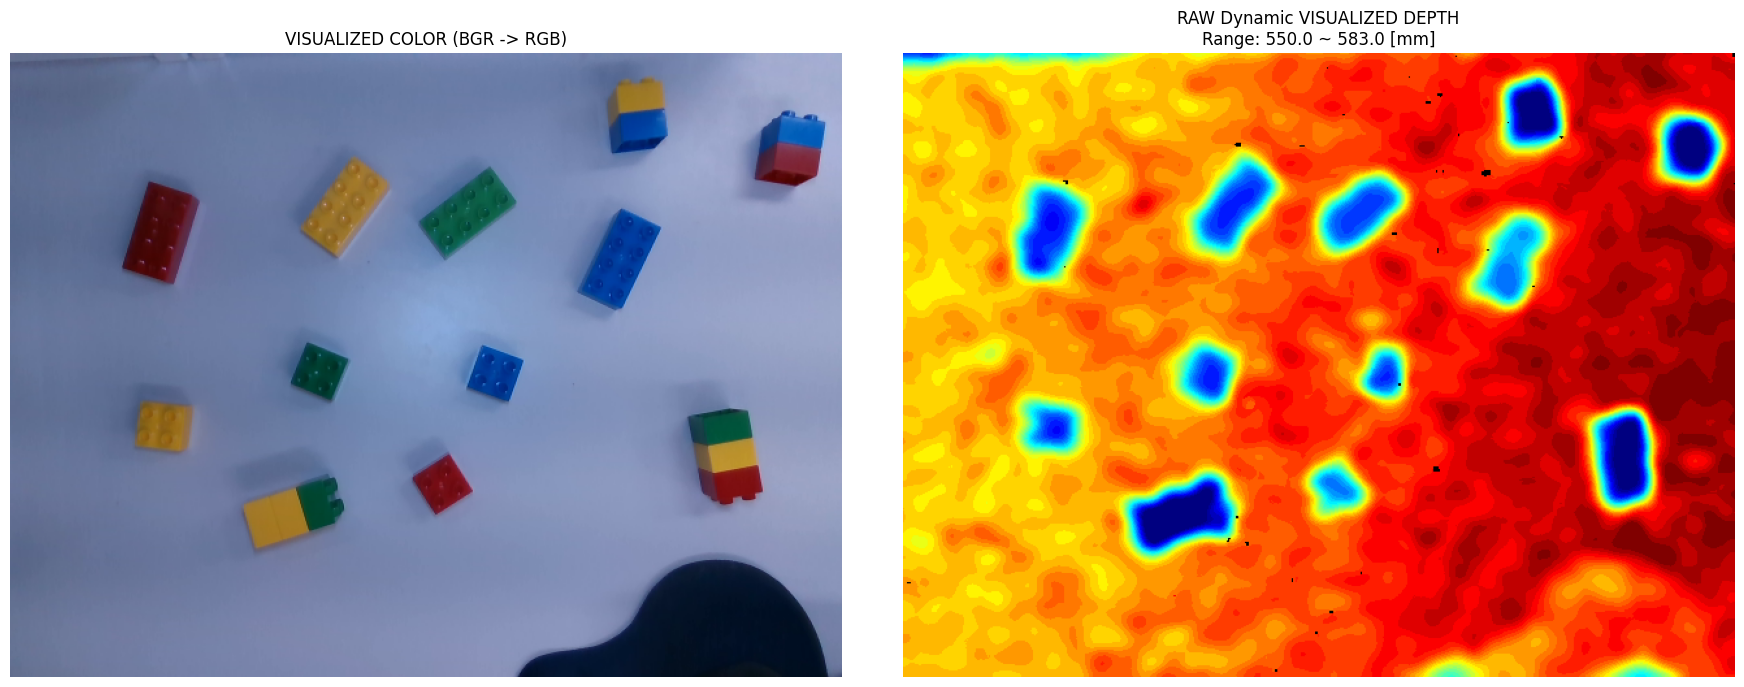

In [44]:
# ---------------------------------------------------------
# 카메라 원본 확인 + 전처리 누적 변수 초기화
# ---------------------------------------------------------

# 글로벌 변수 - 카메라 원본 이미지
    # color_img_bgr
    # depth_img

# 글로벌 변수 - 처리 완료된 각각의 컬러와 뎁스 저장
    # color_filtered
    # depth_filtered

# 전처리 누적 변수 초기화
color_filtered = color_img_bgr.copy()
depth_filtered = depth_img.copy()

color_filtered_before = color_filtered.copy()
color_filtered_after = color_filtered.copy()

depth_filtered_before = depth_filtered.copy()
depth_filtered_after = depth_filtered.copy()

valid_mask_filtered = (depth_filtered > 0).astype(np.uint8)

print("[INFO] 전처리 누적 변수 초기화 완료")
print(f"[INFO] color_filtered shape: {color_filtered.shape}")
print(f"[INFO] depth_filtered shape: {depth_filtered.shape}")
print(f"[INFO] valid depth pixels: {np.count_nonzero(valid_mask_filtered)}")


# ---------------------------------------------------------
# 카메라 원본 화면 확인
# ---------------------------------------------------------

# 비율에 맞춰서 이미지 비율 계산
width = 18
height = width * (3 / 8)
figsize = (width, height)

# 1행 2열 figsize에 맞춰서 설정
fig, axes = plt.subplots(1, 2, figsize=figsize)

# 컬러
vis_color_img = cv2.cvtColor(color_filtered, cv2.COLOR_BGR2RGB)
axes[0].imshow(vis_color_img)
axes[0].set_title("VISUALIZED COLOR (BGR -> RGB)")
axes[0].axis("off")

# 뎁스
vis_depth_img, depth_range = depth_dynamic_colorization(depth_filtered)
axes[1].imshow(vis_depth_img)
axes[1].set_title(
    f"RAW Dynamic VISUALIZED DEPTH\n"
    f"Range: {depth_range[0]:.1f} ~ {depth_range[1]:.1f} [mm]"
)
axes[1].axis("off")

# 시각화
plt.tight_layout()
plt.show()

### **[사용 X]인트린직의 신뢰도 판단**

In [ ]:
# import cv2
# import numpy as np


def get_intrinsics_from_dict(intrinsics):
    """
    capture_color_depth_and_save_intrinsics()가 반환한 intrinsics dict에서
    K, dist, depth_scale을 추출한다.

    현재 코드 구조:
    intrinsics["color & depth"]["fx"], ...
    """
    if "color & depth" in intrinsics:
        cam = intrinsics["color & depth"]
    elif "color" in intrinsics:
        cam = intrinsics["color"]
    else:
        raise KeyError("intrinsics 안에 'color & depth' 또는 'color' 키가 없습니다.")

    fx = float(cam["fx"])
    fy = float(cam["fy"])
    cx = float(cam["cx"])
    cy = float(cam["cy"])

    K = np.array([
        [fx, 0.0, cx],
        [0.0, fy, cy],
        [0.0, 0.0, 1.0]
    ], dtype=np.float64)

    coeffs = cam.get("coeffs", [0, 0, 0, 0, 0])
    dist = np.array(coeffs, dtype=np.float64).reshape(-1, 1)

    depth_scale = float(cam.get("depth_scale", 0.001))

    return K, dist, depth_scale


def make_checkerboard_object_points(pattern_size=(8, 6), square_size_mm=30.0):
    """
    체커보드 내부 코너의 실제 3D 좌표 생성.
    pattern_size = (가로 내부 코너 수, 세로 내부 코너 수)
    예: findChessboardCorners(gray, (8, 6))이면 pattern_size=(8,6)
    """
    cols, rows = pattern_size

    objp = np.zeros((rows * cols, 3), np.float32)
    objp[:, :2] = np.mgrid[0:cols, 0:rows].T.reshape(-1, 2)
    objp *= float(square_size_mm)

    return objp.astype(np.float64)


def detect_checkerboard_corners(
    color_img_bgr,
    pattern_size=(8, 6),
    subpix_window=(5, 5),
    show=False
):
    """
    BGR 이미지에서 체커보드 내부 코너 검출.
    반환:
      success, corners, debug_img
    """
    gray = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2GRAY)

    flags = (
        cv2.CALIB_CB_ADAPTIVE_THRESH
        | cv2.CALIB_CB_NORMALIZE_IMAGE
        | cv2.CALIB_CB_FAST_CHECK
    )

    success, corners = cv2.findChessboardCorners(gray, pattern_size, flags)

    debug_img = color_img_bgr.copy()

    if not success:
        return False, None, debug_img

    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        30,
        0.001
    )

    corners_refined = cv2.cornerSubPix(
        gray,
        corners,
        subpix_window,
        (-1, -1),
        criteria
    )

    cv2.drawChessboardCorners(debug_img, pattern_size, corners_refined, success)

    if show:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        plt.title("Detected Checkerboard Corners")
        plt.axis("off")
        plt.show()

    return True, corners_refined, debug_img


def compute_sdk_reprojection_error(
    color_img_bgr,
    intrinsics,
    pattern_size=(8, 6),
    square_size_mm=30.0,
    show=False
):
    """
    SDK intrinsics를 사용해서 체커보드 reprojection error를 계산한다.

    과정:
    1. 체커보드 코너 검출
    2. SDK K, dist 사용
    3. solvePnP로 체커보드 pose 추정
    4. projectPoints로 다시 투영
    5. 검출 코너와 투영 코너의 픽셀 오차 계산

    반환:
      report, debug_img
    """
    K, dist, _ = get_intrinsics_from_dict(intrinsics)

    success, corners, debug_img = detect_checkerboard_corners(
        color_img_bgr,
        pattern_size=pattern_size,
        show=False
    )

    if not success:
        return {
            "success": False,
            "reason": "checkerboard_not_found"
        }, debug_img

    objp = make_checkerboard_object_points(
        pattern_size=pattern_size,
        square_size_mm=square_size_mm
    )

    image_points = corners.reshape(-1, 2).astype(np.float64)

    ok, rvec, tvec = cv2.solvePnP(
        objp,
        image_points,
        K,
        dist,
        flags=cv2.SOLVEPNP_ITERATIVE
    )

    if not ok:
        return {
            "success": False,
            "reason": "solvePnP_failed"
        }, debug_img

    projected, _ = cv2.projectPoints(objp, rvec, tvec, K, dist)
    projected = projected.reshape(-1, 2)

    errors = np.linalg.norm(image_points - projected, axis=1)

    mean_error = float(np.mean(errors))
    rms_error = float(np.sqrt(np.mean(errors ** 2)))
    max_error = float(np.max(errors))
    std_error = float(np.std(errors))

    # debug draw
    for p_det, p_proj in zip(image_points, projected):
        p_det = tuple(np.round(p_det).astype(int))
        p_proj = tuple(np.round(p_proj).astype(int))

        cv2.circle(debug_img, p_det, 4, (0, 255, 0), -1)      # detected: green
        cv2.circle(debug_img, p_proj, 3, (0, 0, 255), -1)     # projected: red
        cv2.line(debug_img, p_det, p_proj, (255, 0, 0), 1)

    if show:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        plt.title(f"SDK Reprojection RMS: {rms_error:.3f} px")
        plt.axis("off")
        plt.show()

    report = {
        "success": True,
        "mode": "sdk_intrinsics_reprojection_check",
        "num_corners": int(len(image_points)),
        "mean_error_px": mean_error,
        "rms_error_px": rms_error,
        "std_error_px": std_error,
        "max_error_px": max_error,
        "rvec": rvec.flatten().tolist(),
        "tvec_mm": tvec.flatten().tolist(),
        "K": K.tolist(),
        "dist": dist.flatten().tolist(),
    }

    return report, debug_img


def deproject_pixel_to_point(u, v, z_m, K):
    """
    pinhole 모델 기반 deprojection.
    z_m: meter
    반환: meter 단위 3D point
    """
    fx = K[0, 0]
    fy = K[1, 1]
    cx = K[0, 2]
    cy = K[1, 2]

    x = (u - cx) * z_m / fx
    y = (v - cy) * z_m / fy
    z = z_m

    return np.array([x, y, z], dtype=np.float64)


def compute_checkerboard_depth_plane_rms(
    color_img_bgr,
    depth_img,
    intrinsics,
    pattern_size=(8, 6),
    square_size_mm=30.0,
    sample_stride=4,
    erode_px=5,
    show=False
):
    """
    체커보드 영역의 aligned depth를 3D point cloud로 바꾼 뒤,
    평면 fitting RMS를 mm 단위로 계산한다.

    이 값은 RGB intrinsics보다 depth 품질/평면성 확인에 더 직접적임.
    """
    K, _, depth_scale = get_intrinsics_from_dict(intrinsics)

    success, corners, debug_img = detect_checkerboard_corners(
        color_img_bgr,
        pattern_size=pattern_size,
        show=False
    )

    if not success:
        return {
            "success": False,
            "reason": "checkerboard_not_found"
        }, debug_img

    h, w = depth_img.shape[:2]

    # 체커보드 코너를 감싸는 convex hull mask 생성
    pts = corners.reshape(-1, 2).astype(np.int32)
    hull = cv2.convexHull(pts)

    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillConvexPoly(mask, hull, 255)

    if erode_px > 0:
        kernel = np.ones((erode_px, erode_px), np.uint8)
        mask = cv2.erode(mask, kernel, iterations=1)

    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return {
            "success": False,
            "reason": "empty_checkerboard_mask"
        }, debug_img

    # stride 샘플링
    xs = xs[::sample_stride]
    ys = ys[::sample_stride]

    points = []
    for u, v in zip(xs, ys):
        raw_z = depth_img[v, u]
        if raw_z <= 0:
            continue

        z_m = float(raw_z) * depth_scale
        if z_m <= 0:
            continue

        p = deproject_pixel_to_point(u, v, z_m, K)
        points.append(p)

    if len(points) < 30:
        return {
            "success": False,
            "reason": "not_enough_valid_depth_points",
            "num_points": int(len(points))
        }, debug_img

    points = np.asarray(points, dtype=np.float64)

    # SVD 기반 plane fitting
    centroid = np.mean(points, axis=0)
    centered = points - centroid

    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    normal = vh[-1, :]
    normal = normal / np.linalg.norm(normal)

    # point-to-plane distance
    distances_m = centered @ normal
    distances_mm = distances_m * 1000.0

    rms_mm = float(np.sqrt(np.mean(distances_mm ** 2)))
    mean_abs_mm = float(np.mean(np.abs(distances_mm)))
    max_abs_mm = float(np.max(np.abs(distances_mm)))
    std_mm = float(np.std(distances_mm))

    # debug draw
    overlay = debug_img.copy()
    overlay[mask > 0] = (0.5 * overlay[mask > 0] + 0.5 * np.array([0, 255, 255])).astype(np.uint8)
    debug_img = overlay

    cv2.putText(
        debug_img,
        f"Depth plane RMS: {rms_mm:.2f} mm",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 0, 255),
        2
    )

    if show:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Depth Plane RMS: {rms_mm:.2f} mm")
        plt.axis("off")
        plt.show()

    report = {
        "success": True,
        "mode": "checkerboard_depth_plane_rms",
        "num_points": int(len(points)),
        "rms_mm": rms_mm,
        "mean_abs_mm": mean_abs_mm,
        "std_mm": std_mm,
        "max_abs_mm": max_abs_mm,
        "plane_centroid_m": centroid.tolist(),
        "plane_normal": normal.tolist(),
        "depth_scale": depth_scale,
    }

    return report, debug_img


def check_realsense_calibration_once(
    color_img_bgr,
    depth_img,
    intrinsics,
    pattern_size=(8, 6),
    square_size_mm=30.0,
    show=True
):
    """
    한 장의 color/depth/intrinsics로 실행하는 종합 검증 함수.

    반환:
      result = {
        "reprojection": ...,
        "depth_plane": ...,
        "judgement": ...
      }
    """
    reproj_report, reproj_debug = compute_sdk_reprojection_error(
        color_img_bgr=color_img_bgr,
        intrinsics=intrinsics,
        pattern_size=pattern_size,
        square_size_mm=square_size_mm,
        show=show
    )

    plane_report, plane_debug = compute_checkerboard_depth_plane_rms(
        color_img_bgr=color_img_bgr,
        depth_img=depth_img,
        intrinsics=intrinsics,
        pattern_size=pattern_size,
        square_size_mm=square_size_mm,
        show=show
    )

    judgement = {
        "rgb_intrinsics_status": "unknown",
        "depth_plane_status": "unknown",
        "notes": []
    }

    if reproj_report.get("success", False):
        rms_px = reproj_report["rms_error_px"]

        if rms_px < 0.5:
            judgement["rgb_intrinsics_status"] = "good"
        elif rms_px < 1.0:
            judgement["rgb_intrinsics_status"] = "warning"
        else:
            judgement["rgb_intrinsics_status"] = "bad"

        judgement["notes"].append(
            f"SDK intrinsics reprojection RMS = {rms_px:.3f} px"
        )
    else:
        judgement["notes"].append(
            f"Reprojection check failed: {reproj_report.get('reason')}"
        )

    if plane_report.get("success", False):
        rms_mm = plane_report["rms_mm"]

        if rms_mm < 2.0:
            judgement["depth_plane_status"] = "good"
        elif rms_mm < 5.0:
            judgement["depth_plane_status"] = "warning"
        else:
            judgement["depth_plane_status"] = "bad"

        judgement["notes"].append(
            f"Depth plane RMS = {rms_mm:.3f} mm"
        )
    else:
        judgement["notes"].append(
            f"Depth plane check failed: {plane_report.get('reason')}"
        )

    result = {
        "reprojection": reproj_report,
        "depth_plane": plane_report,
        "judgement": judgement,
        "debug_images": {
            "reprojection": reproj_debug,
            "depth_plane": plane_debug,
        }
    }

    return result

In [ ]:
# result = check_realsense_calibration_once(
#     color_img_bgr=color_img_bgr,
#     depth_img=depth_img,
#     intrinsics=intrinsics,
#     pattern_size=(7, 5),
#     square_size_mm=30.0,
#     show=True
# )

# result["judgement"]

### **IMAGE LOAD**

In [ ]:
# # ------------------------------------------------------------
# # 1. 이미 로드된 변수가 없거나 None이면 파일에서 로드
# # ------------------------------------------------------------
# if "depth_img" not in globals() or depth_img is None:
#     depth_img = cv2.imread(
#         "output/realsense_depth_filtered_aligned.png",
#         cv2.IMREAD_UNCHANGED
#     )

# if "color_img_bgr" not in globals() or color_img_bgr is None:
#     color_img_bgr = cv2.imread(
#         "output/realsense_color.png",
#         cv2.IMREAD_COLOR
#     )

# if depth_img is None:
#     raise FileNotFoundError("depth image를 읽지 못했습니다.")

# if color_img_bgr is None:
#     raise FileNotFoundError("color image를 읽지 못했습니다.")

# # ------------------------------------------------------------
# # 2. depth는 2D로 정리
# # ------------------------------------------------------------
# if depth_img.ndim == 3 and depth_img.shape[2] == 1:
#     depth_img = depth_img[:, :, 0]

# if depth_img.ndim != 2:
#     raise ValueError(f"depth_img는 2D depth 이미지여야 합니다. 현재 shape: {depth_img.shape}")

# # ------------------------------------------------------------
# # 4. color는 3채널 유지
# # ------------------------------------------------------------
# if color_img_bgr.ndim != 3 or color_img_bgr.shape[2] != 3:
#     raise ValueError(f"color_img_bgr는 HxWx3 컬러 이미지여야 합니다. 현재 shape: {color_img_bgr.shape}")

# # ------------------------------------------------------------
# # 5. 정보 출력
# # ------------------------------------------------------------
# print("depth:", type(depth_img), depth_img.shape, depth_img.dtype, depth_img.min(), depth_img.max())
# print("color:", type(color_img_bgr), color_img_bgr.shape, color_img_bgr.dtype, color_img_bgr.min(), color_img_bgr.max())

depth: <class 'numpy.ndarray'> (480, 640) uint16 0 645
color: <class 'numpy.ndarray'> (480, 640, 3) uint8 0 255


In [ ]:
# VISUALIZE_COLOR_AND_DEPTH(color_img_bgr, depth_img)

<hr style="height: 10px; background-color: #39FF14; border: none;">

# **전처리 시작**
<hr style="height: 5px; background-color: #39FF14; border: none;">

In [ ]:
### 시각화 대비용 함수
def compare_depth(color_filtered, depth_filtered_before, depth_filtered_after):
    # 글로벌 변수 - 카메라 원본 이미지
        # color_img_bgr
        # depth_img

    # 글로벌 변수 - 처리 완료된 각각의 컬러와 뎁스 저장
        # color_filtered
        # depth_filtered

    # 비율에 맞춰서 이미지 비율 계산
    width = 18
    height = width * (3 / 8)
    figsize = (width, height)

    # 1행 3열 figsize에 맞춰서 설정
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # 컬러
    vis_color_img = cv2.cvtColor(color_filtered, cv2.COLOR_BGR2RGB)
    axes[0].imshow(vis_color_img)
    axes[0].set_title("VISUALIZED COLOR (BGR -> RGB)")
    axes[0].axis("off")

    # 뎁스 비포
    vis_depth_img, depth_range = depth_dynamic_colorization(depth_filtered_before)
    axes[1].imshow(vis_depth_img)
    axes[1].set_title(
        f"Dynamic VISUALIZED DEPTH [before]\n"
        f"Range: {depth_range[0]:.1f} ~ {depth_range[1]:.1f} [mm]"
    )
    axes[1].axis("off")

    # 뎁스 애프터
    vis_depth_img, depth_range = depth_dynamic_colorization(depth_filtered_after)
    axes[2].imshow(vis_depth_img)
    axes[2].set_title(
        f"Dynamic VISUALIZED DEPTH [after]\n"
        f"Range: {depth_range[0]:.1f} ~ {depth_range[1]:.1f} [mm]"
    )
    axes[2].axis("off")

    # 시각화
    plt.tight_layout()
    plt.show()


def compare_color(color_filtered_before, color_filtered_after, depth_filtered):
    # 글로벌 변수 - 카메라 원본 이미지
        # color_img_bgr
        # depth_img

    # 글로벌 변수 - 처리 완료된 각각의 컬러와 뎁스 저장
        # color_filtered
        # depth_filtered

    # 비율에 맞춰서 이미지 비율 계산
    width = 18
    height = width * (3 / 8)
    figsize = (width, height)

    # 1행 3열 figsize에 맞춰서 설정
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # 컬러 비포
    vis_color_img = cv2.cvtColor(color_filtered_before, cv2.COLOR_BGR2RGB)
    axes[0].imshow(vis_color_img)
    axes[0].set_title("VISUALIZED COLOR [before] (BGR -> RGB)")
    axes[0].axis("off")

    # 컬러 애프터
    vis_color_img = cv2.cvtColor(color_filtered_after, cv2.COLOR_BGR2RGB)
    axes[1].imshow(vis_color_img)
    axes[1].set_title("VISUALIZED COLOR [after] (BGR -> RGB)")
    axes[1].axis("off")

    # 뎁스
    vis_depth_img, depth_range = depth_dynamic_colorization(depth_filtered)
    axes[2].imshow(vis_depth_img)
    axes[2].set_title(
        f"Dynamic VISUALIZED DEPTH\n"
        f"Range: {depth_range[0]:.1f} ~ {depth_range[1]:.1f} [mm]"
    )
    axes[2].axis("off")

    # 시각화
    plt.tight_layout()
    plt.show()

```
depth_filtered = 누적 확정본
depth_filtered_before = 이번 처리 전
depth_filtered_after = 이번 처리 후
시각화 후 depth_filtered = depth_filtered_after.copy()
```

```
color_img_bgr / depth_img
→ 카메라 원본. 절대 안 건드림.

color_filtered / depth_filtered
→ 현재까지 전처리가 확정된 누적 결과.

color_filtered_before / depth_filtered_before
→ 이번 전처리 전 상태.

color_filtered_after / depth_filtered_after
→ 이번 전처리 후 상태.
```

## **INVALID EROSION**

In [45]:
def apply_valid_mask_erosion(
    depth_img,
    valid_mask=None,
    erosion_kernel=3,
    iterations=1,
    apply_to_depth=True
):
    """
    depth image의 valid mask를 erosion하여 invalid 주변부를 제거한다.

    Parameters
    ----------
    depth_img : np.ndarray
        입력 depth image.

    valid_mask : np.ndarray or None
        valid depth mask. None이면 depth_img > 0 기준.

    erosion_kernel : int
        erosion kernel size. 3, 5 권장.

    iterations : int
        erosion 반복 횟수.

    apply_to_depth : bool
        True이면 erosion된 valid mask를 depth에 적용하여 invalid 주변 depth를 0으로 만든다.
        False이면 eroded valid mask만 반환한다.

    Returns
    -------
    depth_eroded : np.ndarray
        erosion mask가 적용된 depth image.

    eroded_valid_mask : np.ndarray
        erosion된 valid mask. 값은 0 또는 1.

    info : dict
        처리 정보.
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if not isinstance(depth_img, np.ndarray):
        raise TypeError("depth_img는 np.ndarray 형식이어야 합니다.")

    if depth_img.ndim != 2:
        raise ValueError(f"depth_img는 2D depth 이미지여야 합니다. 현재 shape: {depth_img.shape}")

    if erosion_kernel is None or erosion_kernel <= 0:
        raise ValueError("erosion_kernel은 1 이상의 정수여야 합니다.")

    if iterations is None or iterations <= 0:
        raise ValueError("iterations는 1 이상의 정수여야 합니다.")

    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        if valid_mask.shape != depth_img.shape:
            raise ValueError("valid_mask와 depth_img의 shape가 다릅니다.")
        valid_bool = (valid_mask > 0) & (depth_img > 0)

    valid_u8 = valid_bool.astype(np.uint8)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (erosion_kernel, erosion_kernel)
    )

    eroded_valid_mask = cv2.erode(
        valid_u8,
        kernel,
        iterations=iterations
    )

    if apply_to_depth:
        depth_eroded = depth_img.copy()
        depth_eroded[eroded_valid_mask == 0] = 0
    else:
        depth_eroded = depth_img.copy()

    info = {
        "filter": "valid_mask_erosion",
        "erosion_kernel": int(erosion_kernel),
        "iterations": int(iterations),
        "apply_to_depth": bool(apply_to_depth),
        "valid_pixels_before": int(np.count_nonzero(valid_u8)),
        "valid_pixels_after": int(np.count_nonzero(eroded_valid_mask)),
        "removed_pixels": int(np.count_nonzero(valid_u8) - np.count_nonzero(eroded_valid_mask)),
    }

    return depth_eroded, eroded_valid_mask, info

In [46]:
# ---------------------------------------------------------
# Invalid Erosion 실행부
# ---------------------------------------------------------

depth_filtered_before = depth_filtered.copy()

valid_mask = (depth_filtered_before > 0).astype(np.uint8)

depth_eroded, valid_mask_eroded, erosion_info = apply_valid_mask_erosion(
    depth_img=depth_filtered_before,
    valid_mask=valid_mask,
    erosion_kernel=5,
    iterations=1,
    apply_to_depth=True
)

depth_filtered_after = depth_eroded.copy()
valid_mask_filtered_after = valid_mask_eroded.copy()

print("\n[Invalid Erosion 결과 통계]")
pprint.pprint(erosion_info, sort_dicts=False)


[Invalid Erosion 결과 통계]
{'filter': 'valid_mask_erosion',
 'erosion_kernel': 5,
 'iterations': 1,
 'apply_to_depth': True,
 'valid_pixels_before': 307030,
 'valid_pixels_after': 306211,
 'removed_pixels': 819}


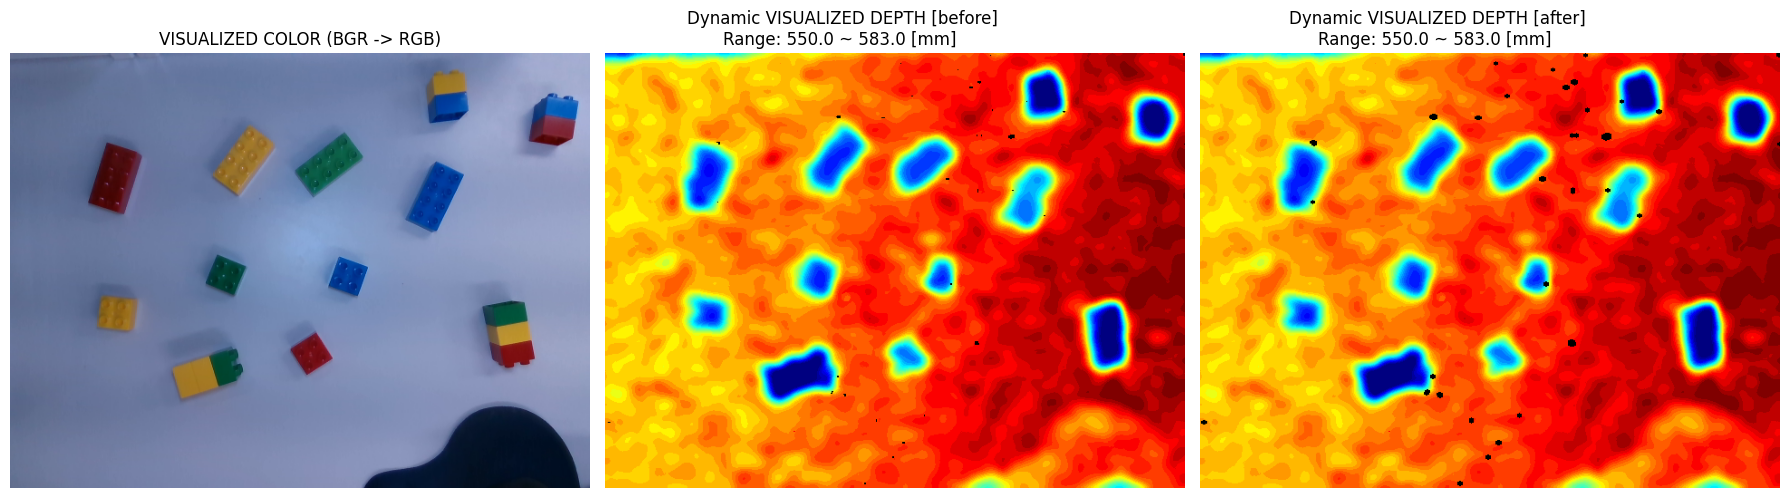


[INFO] depth_filtered = depth_filtered_after 으로 갱신되었습니다.
[INFO] valid_mask_filtered = valid_mask_filtered_after 으로 갱신되었습니다.


In [47]:
# ---------------------------------------------------------
# Invalid Erosion 시각화 및 갱신부
# ---------------------------------------------------------

compare_depth(
    color_filtered=color_filtered,
    depth_filtered_before=depth_filtered_before,
    depth_filtered_after=depth_filtered_after
)

depth_filtered = depth_filtered_after.copy()
valid_mask_filtered = valid_mask_filtered_after.copy()

print("\n[INFO] depth_filtered = depth_filtered_after 으로 갱신되었습니다.")
print("[INFO] valid_mask_filtered = valid_mask_filtered_after 으로 갱신되었습니다.")

---

## **MEDIAN**

In [ ]:
def apply_depth_median_filter(
    depth_img,
    ksize=5,
    valid_mask=None,
    fill_holes=True,
    restore_invalid=True,
    hole_fill_ksize=3
):
    """
    depth 이미지에 median filter를 적용한다.

    목적
    ----
    RealSense depth에서 튀는 점과 salt-pepper 형태의 노이즈를 줄인다.
    단, invalid depth=0 때문에 median filter가 객체 경계를 파먹는 문제를 줄이기 위해
    선택적으로 invalid 영역을 주변 valid median 값으로 임시 보정한 뒤 median filter를 수행한다.

    Parameters
    ----------
    depth_img : np.ndarray
        입력 depth image.

    ksize : int
        median filter kernel size. 3 이상의 홀수.

    valid_mask : np.ndarray or None
        유효 depth mask. 1 또는 255 = valid.
        None이면 depth_img > 0 기준으로 생성.

    fill_holes : bool
        True이면 median filter 전에 invalid=0 영역을 주변 valid median 값으로 임시 보정한다.

    restore_invalid : bool
        True이면 원래 invalid였던 픽셀은 최종 결과에서도 0으로 되돌린다.

    hole_fill_ksize : int
        invalid 임시 보정에 사용할 주변 kernel size. 3, 5 정도 권장.

    Returns
    -------
    depth_filtered : np.ndarray
        median filter가 적용된 depth image.

    filter_info : dict
        필터 적용 정보와 통계.
    """

    # ---------------------------------------------------------
    # 0. 입력 검사
    # ---------------------------------------------------------
    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if not isinstance(depth_img, np.ndarray):
        raise TypeError("depth_img는 np.ndarray 형식이어야 합니다.")

    if depth_img.ndim != 2:
        raise ValueError(
            f"depth_img는 2D depth 이미지여야 합니다. 현재 shape: {depth_img.shape}"
        )

    if ksize % 2 == 0 or ksize < 3:
        raise ValueError("ksize는 최소 3 이상의 홀수여야 합니다. 예: 3, 5, 7")

    if hole_fill_ksize % 2 == 0 or hole_fill_ksize < 3:
        raise ValueError("hole_fill_ksize는 최소 3 이상의 홀수여야 합니다. 예: 3, 5")

    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        if valid_mask.shape != depth_img.shape:
            raise ValueError("valid_mask와 depth_img의 shape가 다릅니다.")
        valid_bool = (valid_mask > 0) & (depth_img > 0)

    original_invalid_bool = ~valid_bool

    # ---------------------------------------------------------
    # 1. median filter 전 invalid=0 임시 보정
    # ---------------------------------------------------------
    depth_to_filter = depth_img.copy()
    filled_pixel_count = 0

    if fill_holes:
        depth_float = depth_img.astype(np.float32)

        pad = hole_fill_ksize // 2

        padded_depth = np.pad(
            depth_float,
            pad_width=pad,
            mode="edge"
        )

        padded_valid = np.pad(
            valid_bool.astype(np.uint8),
            pad_width=pad,
            mode="constant",
            constant_values=0
        )

        filled_depth = depth_float.copy()

        invalid_y, invalid_x = np.where(~valid_bool)

        for y, x in zip(invalid_y, invalid_x):
            y0 = y
            x0 = x

            local_depth = padded_depth[
                y0:y0 + hole_fill_ksize,
                x0:x0 + hole_fill_ksize
            ]

            local_valid = padded_valid[
                y0:y0 + hole_fill_ksize,
                x0:x0 + hole_fill_ksize
            ] > 0

            local_values = local_depth[local_valid]

            if local_values.size > 0:
                filled_depth[y, x] = np.median(local_values)
                filled_pixel_count += 1

        if np.issubdtype(depth_img.dtype, np.integer):
            depth_to_filter = np.clip(
                filled_depth,
                0,
                np.iinfo(depth_img.dtype).max
            ).astype(depth_img.dtype)
        else:
            depth_to_filter = filled_depth.astype(depth_img.dtype)

    # ---------------------------------------------------------
    # 2. Median Filtering
    # ---------------------------------------------------------
    depth_filtered = cv2.medianBlur(depth_to_filter, ksize)

    # ---------------------------------------------------------
    # 3. 원래 invalid 영역 복원
    # ---------------------------------------------------------
    if restore_invalid:
        depth_filtered[original_invalid_bool] = 0

    # ---------------------------------------------------------
    # 4. 통계 정보 계산
    # ---------------------------------------------------------
    valid_before = depth_img[valid_bool]
    valid_after = depth_filtered[valid_bool]

    before_median = float(np.median(valid_before)) if valid_before.size > 0 else None
    before_mean = float(np.mean(valid_before)) if valid_before.size > 0 else None
    before_std = float(np.std(valid_before)) if valid_before.size > 0 else None

    after_median = float(np.median(valid_after)) if valid_after.size > 0 else None
    after_mean = float(np.mean(valid_after)) if valid_after.size > 0 else None
    after_std = float(np.std(valid_after)) if valid_after.size > 0 else None

    valid_after_bool = depth_filtered > 0

    diff = cv2.absdiff(depth_img, depth_filtered)
    diff_valid = diff[valid_bool]

    diff_mean = float(np.mean(diff_valid)) if diff_valid.size > 0 else None
    diff_median = float(np.median(diff_valid)) if diff_valid.size > 0 else None
    diff_max = float(np.max(diff_valid)) if diff_valid.size > 0 else None

    filter_info = {
        "filter": "median",
        "ksize": int(ksize),
        "fill_holes": bool(fill_holes),
        "restore_invalid": bool(restore_invalid),
        "hole_fill_ksize": int(hole_fill_ksize),
        "filled_pixel_count": int(filled_pixel_count),

        "valid_pixels_before": int(np.count_nonzero(valid_bool)),
        "valid_pixels_after": int(np.count_nonzero(valid_after_bool)),
        "zero_pixels_before": int(np.count_nonzero(depth_img == 0)),
        "zero_pixels_after": int(np.count_nonzero(depth_filtered == 0)),

        "before_median_raw": before_median,
        "before_mean_raw": before_mean,
        "before_std_raw": before_std,

        "after_median_raw": after_median,
        "after_mean_raw": after_mean,
        "after_std_raw": after_std,

        "diff_mean_raw": diff_mean,
        "diff_median_raw": diff_median,
        "diff_max_raw": diff_max,
    }

    return depth_filtered, filter_info

In [48]:
# ---------------------------------------------------------
# Depth Median Filter 실행부
# ---------------------------------------------------------

depth_filtered_before = depth_filtered.copy()

valid_mask = (depth_filtered_before > 0).astype(np.uint8)

depth_median, median_info = apply_depth_median_filter(
    depth_img=depth_filtered_before,
    ksize=5,
    valid_mask=valid_mask,
    fill_holes=True,
    restore_invalid=True,
    hole_fill_ksize=3
)

depth_filtered_after = depth_median.copy()
valid_mask_filtered_after = (depth_filtered_after > 0).astype(np.uint8)

print("\n[Depth Median Filter 결과 통계]")
pprint.pprint(median_info, sort_dicts=False)


[Depth Median Filter 결과 통계]
{'filter': 'median',
 'ksize': 5,
 'fill_holes': True,
 'restore_invalid': True,
 'hole_fill_ksize': 3,
 'filled_pixel_count': 645,
 'valid_pixels_before': 306211,
 'valid_pixels_after': 306211,
 'zero_pixels_before': 989,
 'zero_pixels_after': 989,
 'before_median_raw': 576.0,
 'before_mean_raw': 574.7731890755067,
 'before_std_raw': 6.307559223791964,
 'after_median_raw': 576.0,
 'after_mean_raw': 574.7752856690321,
 'after_std_raw': 6.2976188949007685,
 'diff_mean_raw': 0.02061323727756351,
 'diff_median_raw': 0.0,
 'diff_max_raw': 4.0}


---

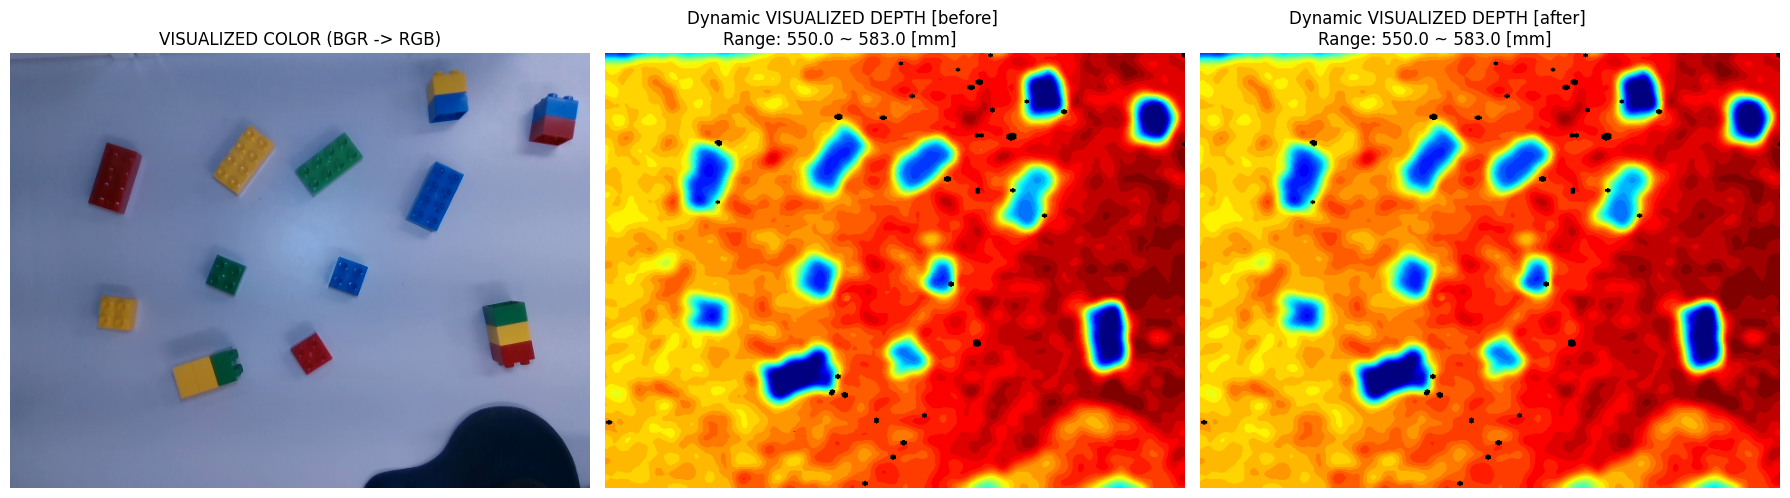


[INFO] depth_filtered = depth_filtered_after 으로 갱신되었습니다.
[INFO] valid_mask_filtered = valid_mask_filtered_after 으로 갱신되었습니다.


In [50]:
# ---------------------------------------------------------
# Depth Median Filter 시각화 및 갱신부
# ---------------------------------------------------------

compare_depth(
    color_filtered=color_filtered,
    depth_filtered_before=depth_filtered_before,
    depth_filtered_after=depth_filtered_after
)

depth_filtered = depth_filtered_after.copy()
valid_mask_filtered = valid_mask_filtered_after.copy()

print("\n[INFO] depth_filtered = depth_filtered_after 으로 갱신되었습니다.")
print("[INFO] valid_mask_filtered = valid_mask_filtered_after 으로 갱신되었습니다.")

# **전처리 종료 및 머신 러닝 클러스터링 및 마스킹 시작**
<hr style="height: 5px; background-color: #39FF14; border: none;">

# **RANSAC**

<p align="center">
 <img src = "pic/RANSAC_intro.png", width="500px">, <img src = "pic/pointcloud.png", width="500px">
</p>

In [52]:
def get_intrinsics_values(intrinsics):
    """
    intrinsics dict 또는 RealSense intrinsics 객체에서 fx, fy, cx, cy, depth_scale을 추출한다.

    Returns
    -------
    fx, fy, cx, cy : float
        카메라 내부 파라미터.

    depth_to_mm_scale : float
        depth_img raw 값을 mm로 변환하기 위한 scale.
        RealSense depth_scale이 0.001이면 raw * 1.0 = mm.
    """

    if intrinsics is None:
        raise ValueError("intrinsics가 None입니다.")

    # dict 형태
    if isinstance(intrinsics, dict):
        if "color & depth" in intrinsics:
            intr = intrinsics["color & depth"]
        else:
            intr = intrinsics

        fx = float(intr["fx"])
        fy = float(intr["fy"])
        cx = float(intr["cx"])
        cy = float(intr["cy"])

        depth_scale = float(intr.get("depth_scale", 0.001))
        depth_to_mm_scale = depth_scale * 1000.0

    # RealSense intrinsics 객체 형태
    else:
        fx = float(intrinsics.fx)
        fy = float(intrinsics.fy)
        cx = float(intrinsics.ppx)
        cy = float(intrinsics.ppy)

        # depth_scale 정보가 없으면 RealSense 기본 raw unit을 mm로 가정
        depth_to_mm_scale = 1.0

    return fx, fy, cx, cy, depth_to_mm_scale

In [53]:
def depth_to_point_cloud_mm(
    depth_img,
    intrinsics,
    valid_mask=None,
    sample_stride=1
):
    """
    depth image를 camera frame 기준 point cloud로 변환한다.
    단위는 mm.

    Camera coordinate
    -----------------
    X = (u - cx) * Z / fx
    Y = (v - cy) * Z / fy
    Z = depth_mm

    Parameters
    ----------
    depth_img : np.ndarray
        2D depth image.

    intrinsics : dict or RealSense intrinsics
        fx, fy, cx, cy, depth_scale 정보를 포함.

    valid_mask : np.ndarray or None
        사용할 valid mask. None이면 depth_img > 0 기준.

    sample_stride : int
        점군 다운샘플링 stride. RANSAC 속도용.

    Returns
    -------
    points_mm : np.ndarray
        shape = (N, 3), 단위 mm.

    pixels_uv : np.ndarray
        shape = (N, 2), 각 3D point에 대응되는 pixel 좌표 [u, v].

    info : dict
        처리 정보.
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if not isinstance(depth_img, np.ndarray):
        raise TypeError("depth_img는 np.ndarray 형식이어야 합니다.")

    if depth_img.ndim != 2:
        raise ValueError(f"depth_img는 2D depth 이미지여야 합니다. 현재 shape: {depth_img.shape}")

    if sample_stride is None or sample_stride <= 0:
        raise ValueError("sample_stride는 1 이상의 정수여야 합니다.")

    h, w = depth_img.shape

    fx, fy, cx, cy, depth_to_mm_scale = get_intrinsics_values(intrinsics)

    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        if valid_mask.shape != depth_img.shape:
            raise ValueError("valid_mask와 depth_img의 shape가 다릅니다.")
        valid_bool = (valid_mask > 0) & (depth_img > 0)

    # stride 적용
    valid_sample = np.zeros_like(valid_bool, dtype=bool)
    valid_sample[::sample_stride, ::sample_stride] = True
    valid_bool = valid_bool & valid_sample

    v_idx, u_idx = np.where(valid_bool)

    depth_mm = depth_img[v_idx, u_idx].astype(np.float32) * depth_to_mm_scale

    x_mm = (u_idx.astype(np.float32) - cx) * depth_mm / fx
    y_mm = (v_idx.astype(np.float32) - cy) * depth_mm / fy
    z_mm = depth_mm

    points_mm = np.stack([x_mm, y_mm, z_mm], axis=1)
    pixels_uv = np.stack([u_idx, v_idx], axis=1)

    info = {
        "function": "depth_to_point_cloud_mm",
        "image_width": int(w),
        "image_height": int(h),
        "sample_stride": int(sample_stride),
        "num_points": int(points_mm.shape[0]),
        "depth_to_mm_scale": float(depth_to_mm_scale),
        "fx": float(fx),
        "fy": float(fy),
        "cx": float(cx),
        "cy": float(cy),
    }

    return points_mm, pixels_uv, info

In [54]:
def create_ransac_plane_height_map(
    depth_img,
    intrinsics,
    valid_mask=None,
    sample_stride=2,
    distance_threshold_mm=5.0,
    ransac_n=3,
    num_iterations=1000
):
    """
    depth image에서 RANSAC으로 기준 평면을 추정하고,
    해당 평면 기준 signed height map을 생성한다.

    height_map 의미
    ---------------
    카메라 쪽으로 평면보다 튀어나온 방향을 positive height로 둔다.
    즉, 바닥/테이블 위에 놓인 물체는 보통 양수 height를 가진다.

    Parameters
    ----------
    depth_img : np.ndarray
        입력 depth image.

    intrinsics : dict or RealSense intrinsics
        카메라 내부 파라미터.

    valid_mask : np.ndarray or None
        유효 depth mask.

    sample_stride : int
        RANSAC용 point cloud 다운샘플링 stride.

    distance_threshold_mm : float
        RANSAC plane inlier distance threshold. 단위 mm.

    ransac_n : int
        plane fitting에 사용할 최소 점 개수.

    num_iterations : int
        RANSAC 반복 횟수.

    Returns
    -------
    height_map : np.ndarray
        plane 기준 signed height map. 단위 mm. invalid는 0.

    height_valid_mask : np.ndarray
        height 계산이 가능한 valid mask. 값 0 또는 1.

    plane_info : dict
        plane model 및 통계 정보.
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if depth_img.ndim != 2:
        raise ValueError(f"depth_img는 2D depth 이미지여야 합니다. 현재 shape: {depth_img.shape}")

    try:
        import open3d as o3d
    except ImportError:
        raise ImportError("open3d가 필요합니다. pip install open3d 또는 conda install open3d 후 실행하세요.")

    h, w = depth_img.shape

    # ---------------------------------------------------------
    # 1. RANSAC용 point cloud 생성
    # ---------------------------------------------------------
    points_mm, pixels_uv, pc_info = depth_to_point_cloud_mm(
        depth_img=depth_img,
        intrinsics=intrinsics,
        valid_mask=valid_mask,
        sample_stride=sample_stride
    )

    if points_mm.shape[0] < 100:
        raise ValueError(f"RANSAC에 사용할 point가 너무 적습니다. num_points={points_mm.shape[0]}")

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_mm.astype(np.float64))

    # ---------------------------------------------------------
    # 2. RANSAC plane 추정
    # ---------------------------------------------------------
    plane_model, inliers = pcd.segment_plane(
        distance_threshold=float(distance_threshold_mm),
        ransac_n=int(ransac_n),
        num_iterations=int(num_iterations)
    )

    a, b, c, d = [float(v) for v in plane_model]

    normal = np.array([a, b, c], dtype=np.float64)
    normal_norm = np.linalg.norm(normal)

    if normal_norm <= 1e-9:
        raise ValueError("RANSAC plane normal norm이 비정상입니다.")

    normal = normal / normal_norm
    d = d / normal_norm

    # ---------------------------------------------------------
    # 3. normal 방향 정리
    #    plane normal이 카메라 원점 쪽을 향하도록 설정
    # ---------------------------------------------------------
    inlier_points = points_mm[np.asarray(inliers, dtype=np.int64)]
    plane_center = np.mean(inlier_points, axis=0)

    camera_origin = np.array([0.0, 0.0, 0.0], dtype=np.float64)
    camera_side_vec = camera_origin - plane_center

    if np.dot(normal, camera_side_vec) < 0:
        normal = -normal
        d = -d

    # ---------------------------------------------------------
    # 4. 전체 depth image에 대해 height map 생성
    # ---------------------------------------------------------
    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        valid_bool = (valid_mask > 0) & (depth_img > 0)

    fx, fy, cx, cy, depth_to_mm_scale = get_intrinsics_values(intrinsics)

    v_idx, u_idx = np.where(valid_bool)

    depth_mm = depth_img[v_idx, u_idx].astype(np.float32) * depth_to_mm_scale

    x_mm = (u_idx.astype(np.float32) - cx) * depth_mm / fx
    y_mm = (v_idx.astype(np.float32) - cy) * depth_mm / fy
    z_mm = depth_mm

    pts = np.stack([x_mm, y_mm, z_mm], axis=1).astype(np.float64)

    signed_height = pts @ normal + d

    height_map = np.zeros((h, w), dtype=np.float32)
    height_map[v_idx, u_idx] = signed_height.astype(np.float32)

    height_valid_mask = valid_bool.astype(np.uint8)

    # ---------------------------------------------------------
    # 5. 통계 정보
    # ---------------------------------------------------------
    valid_height_values = height_map[height_valid_mask > 0]

    plane_info = {
        "function": "create_ransac_plane_height_map",
        "plane_model": {
            "a": float(normal[0]),
            "b": float(normal[1]),
            "c": float(normal[2]),
            "d": float(d),
            "equation": "ax + by + cz + d = 0",
            "unit": "mm"
        },
        "sample_stride": int(sample_stride),
        "distance_threshold_mm": float(distance_threshold_mm),
        "ransac_n": int(ransac_n),
        "num_iterations": int(num_iterations),
        "num_ransac_points": int(points_mm.shape[0]),
        "num_inliers": int(len(inliers)),
        "inlier_ratio": float(len(inliers) / max(points_mm.shape[0], 1)),
        "height_min_mm": float(np.min(valid_height_values)) if valid_height_values.size > 0 else None,
        "height_max_mm": float(np.max(valid_height_values)) if valid_height_values.size > 0 else None,
        "height_mean_mm": float(np.mean(valid_height_values)) if valid_height_values.size > 0 else None,
        "height_std_mm": float(np.std(valid_height_values)) if valid_height_values.size > 0 else None,
        "pointcloud_info": pc_info,
    }

    return height_map, height_valid_mask, plane_info

In [55]:
def create_height_threshold_mask(
    height_map,
    height_valid_mask=None,
    min_height_mm=10.0,
    max_height_mm=120.0,
    morph_kernel=3
):
    """
    RANSAC plane 기준 height map에서 특정 높이 범위의 영역을 마스크로 만든다.

    Parameters
    ----------
    height_map : np.ndarray
        plane 기준 signed height map. 단위 mm.

    height_valid_mask : np.ndarray or None
        height valid mask.

    min_height_mm : float
        물체 후보로 볼 최소 height.

    max_height_mm : float
        너무 튀는 노이즈 제거용 최대 height.

    morph_kernel : int
        morphology open/close kernel size. 0 또는 None이면 적용 안 함.

    Returns
    -------
    height_mask : np.ndarray
        height threshold mask. 값 0 또는 1.

    info : dict
        처리 정보.
    """

    if height_map is None:
        raise ValueError("height_map이 None입니다.")

    if not isinstance(height_map, np.ndarray):
        raise TypeError("height_map은 np.ndarray 형식이어야 합니다.")

    if height_map.ndim != 2:
        raise ValueError(f"height_map은 2D 이미지여야 합니다. 현재 shape: {height_map.shape}")

    if height_valid_mask is None:
        valid_bool = np.ones_like(height_map, dtype=bool)
    else:
        if height_valid_mask.shape != height_map.shape:
            raise ValueError("height_valid_mask와 height_map의 shape가 다릅니다.")
        valid_bool = height_valid_mask > 0

    height_bool = (
        valid_bool &
        (height_map >= float(min_height_mm)) &
        (height_map <= float(max_height_mm))
    )

    height_mask = height_bool.astype(np.uint8)

    if morph_kernel is not None and morph_kernel > 0:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (morph_kernel, morph_kernel)
        )

        height_mask = cv2.morphologyEx(height_mask, cv2.MORPH_OPEN, kernel)
        height_mask = cv2.morphologyEx(height_mask, cv2.MORPH_CLOSE, kernel)

    info = {
        "function": "create_height_threshold_mask",
        "min_height_mm": float(min_height_mm),
        "max_height_mm": float(max_height_mm),
        "morph_kernel": int(morph_kernel) if morph_kernel is not None else None,
        "mask_pixels": int(np.count_nonzero(height_mask)),
        "valid_pixels": int(np.count_nonzero(valid_bool)),
        "mask_ratio": float(np.count_nonzero(height_mask) / max(np.count_nonzero(valid_bool), 1)),
    }

    return height_mask, info

In [56]:
def create_height_gradient_mask(
    height_map,
    height_valid_mask=None,
    blur_ksize=3,
    gradient_operator="scharr",
    threshold_mode="percentile",
    grad_percentile=90.0,
    grad_threshold_mm=5.0,
    dilate_kernel=3
):
    """
    RANSAC plane 기준 height map에서 gradient magnitude를 계산하여
    높이 변화가 큰 영역을 마스크로 만든다.

    Parameters
    ----------
    height_map : np.ndarray
        plane 기준 signed height map. 단위 mm.

    height_valid_mask : np.ndarray or None
        height valid mask.

    blur_ksize : int
        gradient 계산 전 blur kernel size. 0 또는 None이면 미적용.

    gradient_operator : str
        "sobel" 또는 "scharr".

    threshold_mode : str
        "percentile" 또는 "absolute".

    grad_percentile : float
        threshold_mode="percentile"일 때 사용할 percentile.

    grad_threshold_mm : float
        threshold_mode="absolute"일 때 사용할 threshold.

    dilate_kernel : int
        gradient mask dilation kernel size. 0 또는 None이면 미적용.

    Returns
    -------
    gradient_mask : np.ndarray
        height gradient mask. 값 0 또는 1.

    grad_mag : np.ndarray
        height gradient magnitude map.

    info : dict
        처리 정보.
    """

    if height_map is None:
        raise ValueError("height_map이 None입니다.")

    if not isinstance(height_map, np.ndarray):
        raise TypeError("height_map은 np.ndarray 형식이어야 합니다.")

    if height_map.ndim != 2:
        raise ValueError(f"height_map은 2D 이미지여야 합니다. 현재 shape: {height_map.shape}")

    if height_valid_mask is None:
        valid_bool = np.ones_like(height_map, dtype=bool)
    else:
        if height_valid_mask.shape != height_map.shape:
            raise ValueError("height_valid_mask와 height_map의 shape가 다릅니다.")
        valid_bool = height_valid_mask > 0

    height_float = height_map.astype(np.float32).copy()
    height_float[~valid_bool] = 0.0

    # ---------------------------------------------------------
    # 1. Blur
    # ---------------------------------------------------------
    if blur_ksize is not None and blur_ksize > 0:
        if blur_ksize % 2 == 0:
            raise ValueError("blur_ksize는 홀수여야 합니다.")
        height_blur = cv2.GaussianBlur(height_float, (blur_ksize, blur_ksize), 0)
    else:
        height_blur = height_float.copy()

    # ---------------------------------------------------------
    # 2. Gradient
    # ---------------------------------------------------------
    if gradient_operator.lower() == "scharr":
        grad_x = cv2.Scharr(height_blur, cv2.CV_32F, 1, 0)
        grad_y = cv2.Scharr(height_blur, cv2.CV_32F, 0, 1)
    elif gradient_operator.lower() == "sobel":
        grad_x = cv2.Sobel(height_blur, cv2.CV_32F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(height_blur, cv2.CV_32F, 0, 1, ksize=3)
    else:
        raise ValueError("gradient_operator는 'scharr' 또는 'sobel'만 가능합니다.")

    grad_mag = cv2.magnitude(grad_x, grad_y)

    # invalid 주변 gradient가 크게 튀는 것을 줄이기 위해 valid 영역만 사용
    grad_values = grad_mag[valid_bool]

    if grad_values.size == 0:
        raise ValueError("gradient threshold 계산에 사용할 valid pixel이 없습니다.")

    # ---------------------------------------------------------
    # 3. Threshold
    # ---------------------------------------------------------
    if threshold_mode == "percentile":
        threshold_value = float(np.percentile(grad_values, grad_percentile))
    elif threshold_mode == "absolute":
        threshold_value = float(grad_threshold_mm)
    else:
        raise ValueError("threshold_mode는 'percentile' 또는 'absolute'만 가능합니다.")

    gradient_mask = ((grad_mag >= threshold_value) & valid_bool).astype(np.uint8)

    # ---------------------------------------------------------
    # 4. Dilation
    # ---------------------------------------------------------
    if dilate_kernel is not None and dilate_kernel > 0:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (dilate_kernel, dilate_kernel)
        )
        gradient_mask = cv2.dilate(gradient_mask, kernel, iterations=1)

    info = {
        "function": "create_height_gradient_mask",
        "blur_ksize": int(blur_ksize) if blur_ksize is not None else None,
        "gradient_operator": str(gradient_operator),
        "threshold_mode": str(threshold_mode),
        "grad_percentile": float(grad_percentile),
        "grad_threshold_mm": float(grad_threshold_mm),
        "threshold_value": float(threshold_value),
        "dilate_kernel": int(dilate_kernel) if dilate_kernel is not None else None,
        "gradient_mask_pixels": int(np.count_nonzero(gradient_mask)),
        "valid_pixels": int(np.count_nonzero(valid_bool)),
        "gradient_mask_ratio": float(np.count_nonzero(gradient_mask) / max(np.count_nonzero(valid_bool), 1)),
        "grad_mag_min": float(np.min(grad_values)),
        "grad_mag_max": float(np.max(grad_values)),
        "grad_mag_mean": float(np.mean(grad_values)),
        "grad_mag_std": float(np.std(grad_values)),
    }

    return gradient_mask, grad_mag, info

In [57]:
# ---------------------------------------------------------
# RANSAC Plane + Height Map 실행부
# ---------------------------------------------------------

depth_filtered_before = depth_filtered.copy()

valid_mask = (depth_filtered_before > 0).astype(np.uint8)

height_map, height_valid_mask, ransac_info = create_ransac_plane_height_map(
    depth_img=depth_filtered_before,
    intrinsics=intrinsics,
    valid_mask=valid_mask,
    sample_stride=2,
    distance_threshold_mm=5.0,
    ransac_n=3,
    num_iterations=1000
)

print("\n[RANSAC Plane + Height Map 결과 통계]")
pprint.pprint(ransac_info, sort_dicts=False)


[RANSAC Plane + Height Map 결과 통계]
{'function': 'create_ransac_plane_height_map',
 'plane_model': {'a': 0.016725250923454327,
                 'b': -0.0006911211012780049,
                 'c': -0.9998598843503879,
                 'd': 576.7400725080362,
                 'equation': 'ax + by + cz + d = 0',
                 'unit': 'mm'},
 'sample_stride': 2,
 'distance_threshold_mm': 5.0,
 'ransac_n': 3,
 'num_iterations': 1000,
 'num_ransac_points': 76563,
 'num_inliers': 65648,
 'inlier_ratio': 0.8574376657132035,
 'height_min_mm': -5.447199821472168,
 'height_max_mm': 34.094871520996094,
 'height_mean_mm': 1.9086781740188599,
 'height_std_mm': 5.8219990730285645,
 'pointcloud_info': {'function': 'depth_to_point_cloud_mm',
                     'image_width': 640,
                     'image_height': 480,
                     'sample_stride': 2,
                     'num_points': 76563,
                     'depth_to_mm_scale': 1.0000000474974513,
                     'fx': 606.19396

In [58]:
# ---------------------------------------------------------
# Height Threshold Mask 실행부
# ---------------------------------------------------------

height_mask, height_mask_info = create_height_threshold_mask(
    height_map=height_map,
    height_valid_mask=height_valid_mask,
    min_height_mm=10.0,
    max_height_mm=120.0,
    morph_kernel=3
)

print("\n[Height Threshold Mask 결과 통계]")
pprint.pprint(height_mask_info, sort_dicts=False)


[Height Threshold Mask 결과 통계]
{'function': 'create_height_threshold_mask',
 'min_height_mm': 10.0,
 'max_height_mm': 120.0,
 'morph_kernel': 3,
 'mask_pixels': 26209,
 'valid_pixels': 306211,
 'mask_ratio': 0.08559130795431909}


In [59]:
# ---------------------------------------------------------
# Height Gradient Mask 실행부
# ---------------------------------------------------------

height_gradient_mask, height_grad_mag, height_gradient_info = create_height_gradient_mask(
    height_map=height_map,
    height_valid_mask=height_valid_mask,
    blur_ksize=3,
    gradient_operator="scharr",
    threshold_mode="percentile",
    grad_percentile=90.0,
    grad_threshold_mm=5.0,
    dilate_kernel=3
)

print("\n[Height Gradient Mask 결과 통계]")
pprint.pprint(height_gradient_info, sort_dicts=False)


[Height Gradient Mask 결과 통계]
{'function': 'create_height_gradient_mask',
 'blur_ksize': 3,
 'gradient_operator': 'scharr',
 'threshold_mode': 'percentile',
 'grad_percentile': 90.0,
 'grad_threshold_mm': 5.0,
 'threshold_value': 23.269758224487305,
 'dilate_kernel': 3,
 'gradient_mask_pixels': 35662,
 'valid_pixels': 306211,
 'gradient_mask_ratio': 0.11646217804063211,
 'grad_mag_min': 0.0,
 'grad_mag_max': 250.17929077148438,
 'grad_mag_mean': 8.601706504821777,
 'grad_mag_std': 12.072125434875488}


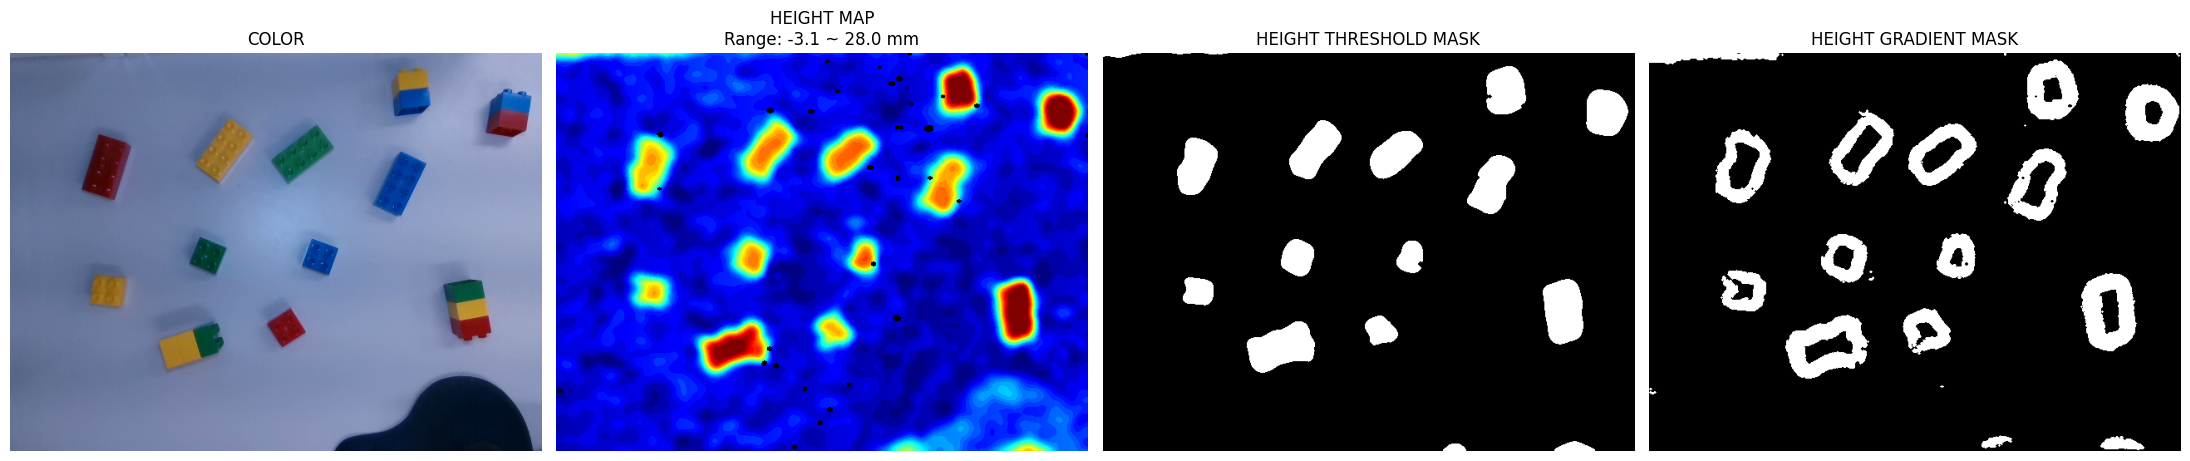

In [60]:
# ---------------------------------------------------------
# Height Map / Mask 시각화
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# 컬러
vis_color_img = cv2.cvtColor(color_filtered, cv2.COLOR_BGR2RGB)
axes[0].imshow(vis_color_img)
axes[0].set_title("COLOR")
axes[0].axis("off")

# Height Map
height_vis = height_map.copy()
height_vis[height_valid_mask == 0] = 0

h_valid = height_vis[height_valid_mask > 0]

if h_valid.size > 0:
    h_min = np.percentile(h_valid, 1)
    h_max = np.percentile(h_valid, 99)

    if h_max <= h_min:
        h_max = h_min + 1.0

    height_norm = np.zeros_like(height_vis, dtype=np.uint8)
    height_clip = np.clip(height_vis, h_min, h_max)
    height_norm[height_valid_mask > 0] = (
        (height_clip[height_valid_mask > 0] - h_min) / (h_max - h_min) * 255
    ).astype(np.uint8)

    height_color = cv2.applyColorMap(height_norm, cv2.COLORMAP_JET)
    height_color[height_valid_mask == 0] = (0, 0, 0)
    height_color = cv2.cvtColor(height_color, cv2.COLOR_BGR2RGB)

    axes[1].imshow(height_color)
    axes[1].set_title(f"HEIGHT MAP\nRange: {h_min:.1f} ~ {h_max:.1f} mm")
else:
    axes[1].imshow(np.zeros_like(height_map), cmap="gray")
    axes[1].set_title("HEIGHT MAP EMPTY")

axes[1].axis("off")

# Height Threshold Mask
axes[2].imshow(height_mask, cmap="gray")
axes[2].set_title("HEIGHT THRESHOLD MASK")
axes[2].axis("off")

# Height Gradient Mask
axes[3].imshow(height_gradient_mask, cmap="gray")
axes[3].set_title("HEIGHT GRADIENT MASK")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## **Depth Candidate Mask 생성 함수**

In [70]:
def create_depth_candidate_mask(
    height_mask,
    height_gradient_mask=None,
    valid_mask=None,
    use_gradient=True,
    morph_kernel=5,
    min_area=100
):
    """
    height threshold mask와 height gradient mask를 결합하여
    depth 기반 객체 후보 마스크를 생성한다.

    Parameters
    ----------
    height_mask : np.ndarray
        height threshold로 생성된 mask. 0 또는 1.

    height_gradient_mask : np.ndarray or None
        height gradient로 생성된 mask. 0 또는 1.

    valid_mask : np.ndarray or None
        유효 depth mask. None이면 적용하지 않음.

    use_gradient : bool
        True이면 height_gradient_mask를 height_mask와 OR로 결합한다.

    morph_kernel : int
        morphology close/open kernel size. 0 또는 None이면 적용하지 않음.

    min_area : int
        connected component 최소 면적. 이보다 작은 component는 제거.

    Returns
    -------
    depth_candidate_mask : np.ndarray
        depth 기반 객체 후보 mask. 값 0 또는 1.

    info : dict
        처리 정보.
    """

    if height_mask is None:
        raise ValueError("height_mask가 None입니다.")

    if not isinstance(height_mask, np.ndarray):
        raise TypeError("height_mask는 np.ndarray 형식이어야 합니다.")

    if height_mask.ndim != 2:
        raise ValueError(f"height_mask는 2D mask여야 합니다. 현재 shape: {height_mask.shape}")

    candidate_bool = height_mask > 0

    if use_gradient and height_gradient_mask is not None:
        if height_gradient_mask.shape != height_mask.shape:
            raise ValueError("height_gradient_mask와 height_mask의 shape가 다릅니다.")
        candidate_bool = candidate_bool | (height_gradient_mask > 0)

    if valid_mask is not None:
        if valid_mask.shape != height_mask.shape:
            raise ValueError("valid_mask와 height_mask의 shape가 다릅니다.")
        candidate_bool = candidate_bool & (valid_mask > 0)

    depth_candidate_mask = candidate_bool.astype(np.uint8)

    # morphology
    if morph_kernel is not None and morph_kernel > 0:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (morph_kernel, morph_kernel)
        )

        depth_candidate_mask = cv2.morphologyEx(
            depth_candidate_mask,
            cv2.MORPH_CLOSE,
            kernel
        )

        depth_candidate_mask = cv2.morphologyEx(
            depth_candidate_mask,
            cv2.MORPH_OPEN,
            kernel
        )

    # 작은 component 제거
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        depth_candidate_mask,
        connectivity=8
    )

    cleaned_mask = np.zeros_like(depth_candidate_mask, dtype=np.uint8)

    kept_components = 0

    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]

        if area >= min_area:
            cleaned_mask[labels == label_id] = 1
            kept_components += 1

    info = {
        "function": "create_depth_candidate_mask",
        "use_gradient": bool(use_gradient),
        "morph_kernel": int(morph_kernel) if morph_kernel is not None else None,
        "min_area": int(min_area),
        "height_mask_pixels": int(np.count_nonzero(height_mask)),
        "height_gradient_mask_pixels": int(np.count_nonzero(height_gradient_mask)) if height_gradient_mask is not None else 0,
        "candidate_pixels_before_area_filter": int(np.count_nonzero(depth_candidate_mask)),
        "candidate_pixels_after_area_filter": int(np.count_nonzero(cleaned_mask)),
        "num_components_total": int(num_labels - 1),
        "num_components_kept": int(kept_components),
    }

    return cleaned_mask, info

## **YOLO Segmentation 실행 함수**

In [71]:
def run_yolo_segmentation_mask(
    color_img_bgr,
    model_path="manip_segmentor_0528.pt",
    target_class_name=None,
    target_class_id=None,
    conf_threshold=0.25,
    select_mode="largest"
):
    """
    YOLOv8 segmentation 모델을 실행하여 target object mask를 생성한다.

    Parameters
    ----------
    color_img_bgr : np.ndarray
        입력 컬러 이미지. BGR 형식.

    model_path : str
        YOLO segmentation model path.

    target_class_name : str or None
        특정 class name만 선택하고 싶을 때 사용.

    target_class_id : int or None
        특정 class id만 선택하고 싶을 때 사용.

    conf_threshold : float
        confidence threshold.

    select_mode : str
        "largest"이면 조건을 만족하는 mask 중 가장 큰 mask 선택.
        "union"이면 조건을 만족하는 mask를 모두 합침.

    Returns
    -------
    yolo_mask : np.ndarray
        YOLO segmentation mask. 0 또는 1.

    yolo_info : dict
        YOLO 검출 정보.
    """

    if color_img_bgr is None:
        raise ValueError("color_img_bgr가 None입니다.")

    if not isinstance(color_img_bgr, np.ndarray):
        raise TypeError("color_img_bgr는 np.ndarray 형식이어야 합니다.")

    if color_img_bgr.ndim != 3:
        raise ValueError(f"color_img_bgr는 3D 컬러 이미지여야 합니다. 현재 shape: {color_img_bgr.shape}")

    if select_mode not in ["largest", "union"]:
        raise ValueError("select_mode는 'largest' 또는 'union'만 가능합니다.")

    try:
        from ultralytics import YOLO
    except ImportError:
        raise ImportError("ultralytics가 필요합니다. pip install ultralytics 후 실행하세요.")

    h, w = color_img_bgr.shape[:2]

    model = YOLO(model_path)

    results = model.predict(
        source=color_img_bgr,
        conf=conf_threshold,
        verbose=False
    )

    if len(results) == 0:
        yolo_mask = np.zeros((h, w), dtype=np.uint8)
        yolo_info = {
            "function": "run_yolo_segmentation_mask",
            "model_path": model_path,
            "status": "NO_RESULT",
            "num_detections": 0,
            "selected_pixels": 0,
        }
        return yolo_mask, yolo_info

    result = results[0]

    if result.masks is None:
        yolo_mask = np.zeros((h, w), dtype=np.uint8)
        yolo_info = {
            "function": "run_yolo_segmentation_mask",
            "model_path": model_path,
            "status": "NO_MASK",
            "num_detections": 0,
            "selected_pixels": 0,
        }
        return yolo_mask, yolo_info

    names = result.names

    boxes = result.boxes
    masks = result.masks.data.cpu().numpy()

    selected_masks = []
    selected_detections = []

    for i in range(len(masks)):
        cls_id = int(boxes.cls[i].item())
        conf = float(boxes.conf[i].item())

        class_name = names.get(cls_id, str(cls_id))

        if conf < conf_threshold:
            continue

        if target_class_id is not None and cls_id != int(target_class_id):
            continue

        if target_class_name is not None and class_name != target_class_name:
            continue

        mask_small = masks[i]

        mask_resized = cv2.resize(
            mask_small.astype(np.float32),
            (w, h),
            interpolation=cv2.INTER_NEAREST
        )

        mask_u8 = (mask_resized > 0.5).astype(np.uint8)

        selected_masks.append(mask_u8)

        selected_detections.append({
            "index": int(i),
            "class_id": int(cls_id),
            "class_name": str(class_name),
            "confidence": float(conf),
            "mask_pixels": int(np.count_nonzero(mask_u8)),
        })

    if len(selected_masks) == 0:
        yolo_mask = np.zeros((h, w), dtype=np.uint8)
        yolo_info = {
            "function": "run_yolo_segmentation_mask",
            "model_path": model_path,
            "status": "NO_SELECTED_MASK",
            "num_detections": int(len(masks)),
            "num_selected": 0,
            "selected_pixels": 0,
            "detections": selected_detections,
            "class_names": names,
        }
        return yolo_mask, yolo_info

    if select_mode == "largest":
        areas = [np.count_nonzero(m) for m in selected_masks]
        best_idx = int(np.argmax(areas))
        yolo_mask = selected_masks[best_idx].astype(np.uint8)
        selected_detection = selected_detections[best_idx]

    else:
        yolo_mask = np.zeros((h, w), dtype=np.uint8)

        for m in selected_masks:
            yolo_mask = ((yolo_mask > 0) | (m > 0)).astype(np.uint8)

        selected_detection = None

    yolo_info = {
        "function": "run_yolo_segmentation_mask",
        "model_path": model_path,
        "status": "OK",
        "target_class_name": target_class_name,
        "target_class_id": int(target_class_id) if target_class_id is not None else None,
        "conf_threshold": float(conf_threshold),
        "select_mode": str(select_mode),
        "num_detections": int(len(masks)),
        "num_selected": int(len(selected_masks)),
        "selected_pixels": int(np.count_nonzero(yolo_mask)),
        "selected_detection": selected_detection,
        "detections": selected_detections,
        "class_names": names,
    }

    return yolo_mask, yolo_info

## **Final Brick Mask 생성 함수**

In [72]:
def create_final_brick_mask(
    depth_candidate_mask,
    yolo_mask,
    valid_mask=None,
    morph_kernel=3,
    min_area=100
):
    """
    depth candidate mask와 YOLO segmentation mask를 AND하여
    최종 brick mask를 생성한다.

    Parameters
    ----------
    depth_candidate_mask : np.ndarray
        depth 기반 후보 mask. 0 또는 1.

    yolo_mask : np.ndarray
        YOLO segmentation mask. 0 또는 1.

    valid_mask : np.ndarray or None
        유효 depth mask.

    morph_kernel : int
        morphology close/open kernel size.

    min_area : int
        최소 component 면적.

    Returns
    -------
    final_brick_mask : np.ndarray
        최종 brick mask. 0 또는 1.

    info : dict
        처리 정보.
    """

    if depth_candidate_mask is None:
        raise ValueError("depth_candidate_mask가 None입니다.")

    if yolo_mask is None:
        raise ValueError("yolo_mask가 None입니다.")

    if depth_candidate_mask.shape != yolo_mask.shape:
        raise ValueError("depth_candidate_mask와 yolo_mask의 shape가 다릅니다.")

    final_bool = (depth_candidate_mask > 0) & (yolo_mask > 0)

    if valid_mask is not None:
        if valid_mask.shape != depth_candidate_mask.shape:
            raise ValueError("valid_mask와 depth_candidate_mask의 shape가 다릅니다.")
        final_bool = final_bool & (valid_mask > 0)

    final_mask = final_bool.astype(np.uint8)

    if morph_kernel is not None and morph_kernel > 0:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (morph_kernel, morph_kernel)
        )

        final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, kernel)
        final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_OPEN, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        final_mask,
        connectivity=8
    )

    cleaned_mask = np.zeros_like(final_mask, dtype=np.uint8)

    kept_components = 0
    largest_area = 0
    largest_label = None

    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]

        if area >= min_area:
            cleaned_mask[labels == label_id] = 1
            kept_components += 1

            if area > largest_area:
                largest_area = int(area)
                largest_label = int(label_id)

    info = {
        "function": "create_final_brick_mask",
        "morph_kernel": int(morph_kernel) if morph_kernel is not None else None,
        "min_area": int(min_area),
        "depth_candidate_pixels": int(np.count_nonzero(depth_candidate_mask)),
        "yolo_mask_pixels": int(np.count_nonzero(yolo_mask)),
        "and_pixels_before_area_filter": int(np.count_nonzero(final_mask)),
        "final_pixels": int(np.count_nonzero(cleaned_mask)),
        "num_components_total": int(num_labels - 1),
        "num_components_kept": int(kept_components),
        "largest_area": int(largest_area),
        "largest_label": largest_label,
    }

    return cleaned_mask, info

## **Overlay 시각화 함수**

In [73]:
def visualize_masks_overlay(
    color_img_bgr,
    depth_candidate_mask=None,
    yolo_mask=None,
    final_mask=None,
    alpha=0.45
):
    """
    color image 위에 depth candidate, YOLO mask, final mask를 비교 시각화한다.

    Parameters
    ----------
    color_img_bgr : np.ndarray
        BGR 컬러 이미지.

    depth_candidate_mask : np.ndarray or None
        depth 기반 후보 mask.

    yolo_mask : np.ndarray or None
        YOLO segmentation mask.

    final_mask : np.ndarray or None
        최종 AND mask.

    alpha : float
        overlay 투명도.
    """

    if color_img_bgr is None:
        raise ValueError("color_img_bgr가 None입니다.")

    color_rgb = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

    masks = []
    titles = []

    if depth_candidate_mask is not None:
        masks.append(depth_candidate_mask)
        titles.append("DEPTH CANDIDATE MASK")

    if yolo_mask is not None:
        masks.append(yolo_mask)
        titles.append("YOLO MASK")

    if final_mask is not None:
        masks.append(final_mask)
        titles.append("FINAL BRICK MASK")

    if len(masks) == 0:
        raise ValueError("시각화할 mask가 없습니다.")

    fig, axes = plt.subplots(1, len(masks) + 1, figsize=(6 * (len(masks) + 1), 5))

    if len(masks) + 1 == 1:
        axes = [axes]

    axes[0].imshow(color_rgb)
    axes[0].set_title("COLOR")
    axes[0].axis("off")

    for i, mask in enumerate(masks):
        if mask.shape[:2] != color_rgb.shape[:2]:
            raise ValueError(f"{titles[i]}와 color image의 shape가 다릅니다.")

        overlay = color_rgb.copy()

        mask_bool = mask > 0

        # 빨간색 overlay
        overlay[mask_bool] = (
            overlay[mask_bool] * (1.0 - alpha) +
            np.array([255, 0, 0]) * alpha
        ).astype(np.uint8)

        axes[i + 1].imshow(overlay)
        axes[i + 1].set_title(f"{titles[i]}\nPixels: {np.count_nonzero(mask)}")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()

## **Depth Candidate Mask**

In [75]:
# ---------------------------------------------------------
# Depth Candidate Mask 실행부
# ---------------------------------------------------------

depth_candidate_mask, depth_candidate_info = create_depth_candidate_mask(
    height_mask=height_mask,
    height_gradient_mask=height_gradient_mask,
    valid_mask=height_valid_mask,
    use_gradient=True,
    morph_kernel=5,
    min_area=100
)

print("\n[Depth Candidate Mask 결과 통계]")
pprint.pprint(depth_candidate_info, sort_dicts=False)


[Depth Candidate Mask 결과 통계]
{'function': 'create_depth_candidate_mask',
 'use_gradient': True,
 'morph_kernel': 5,
 'min_area': 100,
 'height_mask_pixels': 26209,
 'height_gradient_mask_pixels': 35662,
 'candidate_pixels_before_area_filter': 45232,
 'candidate_pixels_after_area_filter': 45232,
 'num_components_total': 15,
 'num_components_kept': 15}


## **YOLO Segmentation Mask**

In [76]:
# ---------------------------------------------------------
# YOLO Segmentation Mask 실행부
# ---------------------------------------------------------

yolo_model_path = "manip_segmentor_0528.pt"

yolo_mask, yolo_info = run_yolo_segmentation_mask(
    color_img_bgr=color_filtered,
    model_path=yolo_model_path,
    target_class_name=None,
    target_class_id=None,
    conf_threshold=0.25,
    select_mode="largest"
)

print("\n[YOLO Segmentation Mask 결과 통계]")
pprint.pprint(yolo_info, sort_dicts=False)


[YOLO Segmentation Mask 결과 통계]
{'function': 'run_yolo_segmentation_mask',
 'model_path': 'manip_segmentor_0528.pt',
 'status': 'OK',
 'target_class_name': None,
 'target_class_id': None,
 'conf_threshold': 0.25,
 'select_mode': 'largest',
 'num_detections': 18,
 'num_selected': 18,
 'selected_pixels': 3144,
 'selected_detection': {'index': 4,
                        'class_id': 8,
                        'class_name': '4x2_red',
                        'confidence': 0.982451856136322,
                        'mask_pixels': 3144},
 'detections': [{'index': 0,
                 'class_id': 4,
                 'class_name': '2x2_yellow',
                 'confidence': 0.9870352149009705,
                 'mask_pixels': 1702},
                {'index': 1,
                 'class_id': 1,
                 'class_name': '2x2_green',
                 'confidence': 0.9858295321464539,
                 'mask_pixels': 1344},
                {'index': 2,
                 'class_id': 3,
           

## **Final Brick Mask**

In [77]:
# ---------------------------------------------------------
# Final Brick Mask 실행부
# ---------------------------------------------------------

final_brick_mask, final_brick_mask_info = create_final_brick_mask(
    depth_candidate_mask=depth_candidate_mask,
    yolo_mask=yolo_mask,
    valid_mask=height_valid_mask,
    morph_kernel=3,
    min_area=100
)

print("\n[Final Brick Mask 결과 통계]")
pprint.pprint(final_brick_mask_info, sort_dicts=False)


[Final Brick Mask 결과 통계]
{'function': 'create_final_brick_mask',
 'morph_kernel': 3,
 'min_area': 100,
 'depth_candidate_pixels': 45232,
 'yolo_mask_pixels': 3144,
 'and_pixels_before_area_filter': 3052,
 'final_pixels': 3052,
 'num_components_total': 1,
 'num_components_kept': 1,
 'largest_area': 3052,
 'largest_label': 1}


## **시각화**

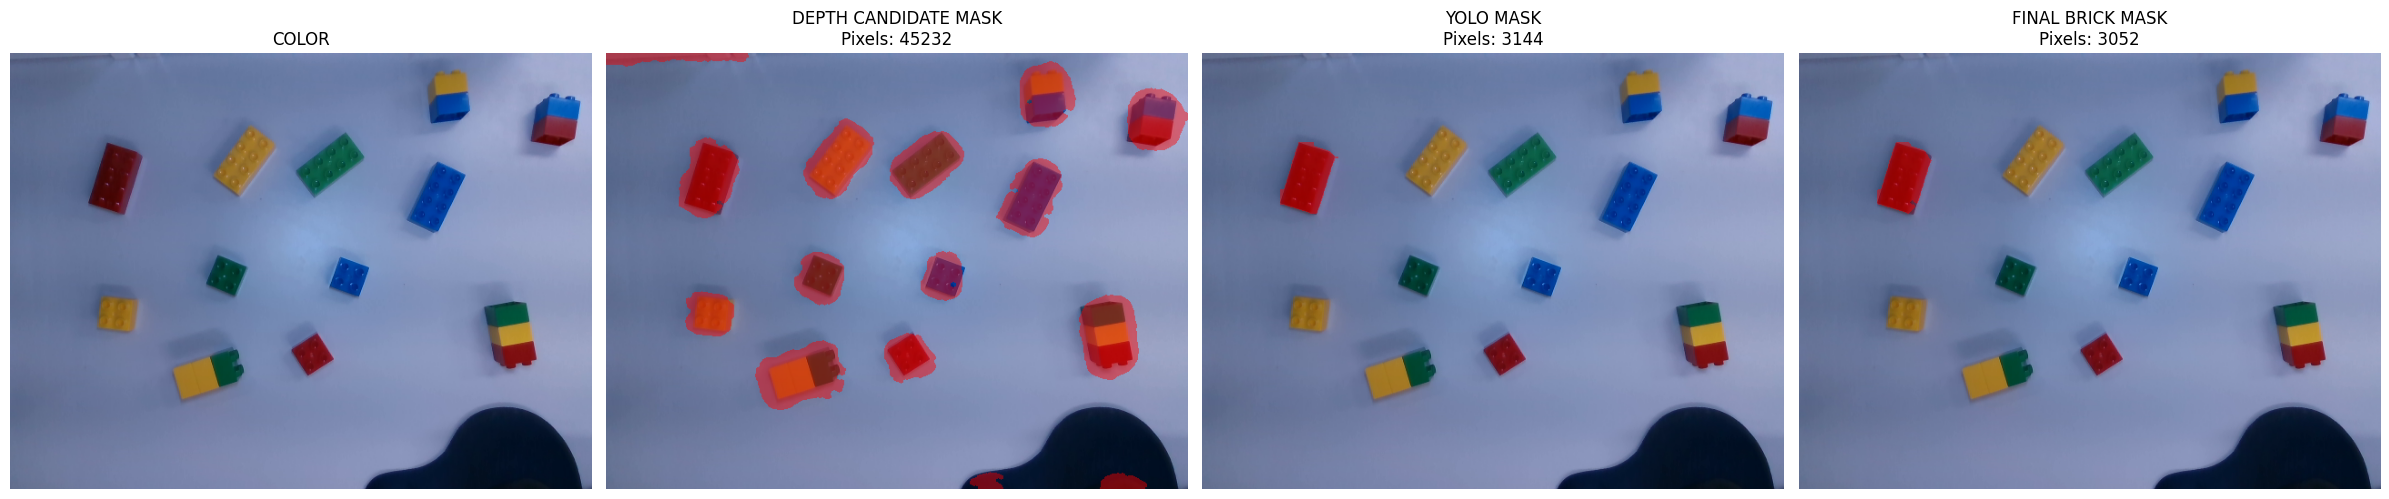

In [78]:
# ---------------------------------------------------------
# Depth / YOLO / Final Mask 시각화
# ---------------------------------------------------------

visualize_masks_overlay(
    color_img_bgr=color_filtered,
    depth_candidate_mask=depth_candidate_mask,
    yolo_mask=yolo_mask,
    final_mask=final_brick_mask,
    alpha=0.45
)